# Multimodal AutoML LOOCV — MSN × FC (cortical 68) + Coupling  [treatment 0/1 · 상호작용 항]

뼈대는 `automl_multimodal_MSN_FC68_coupling_PCA3.ipynb`와 **완전히 동일**하다
(6개 모델 · LOOCV · nested GridSearchCV · fold 안에서 residualize → PCA 3 · 같은 44명 · 같은 그리드).
바뀐 것은 아래 두 가지뿐이다.

## 1. treatment_group 코딩 (이 노트북에서만)
원본 CSV는 `1 = Sham`, `2 = Active`다. 여기서는 **Sham = 0, Active = 1**로 리코딩해 쓴다.
상호작용 항 `PC_k × treatment`가 "Sham 기준선 대비 Active에서의 기울기 차이"로 해석되려면
Sham이 0이어야 하기 때문이다. 1/2 코딩이면 곱 항이 두 군 모두에서 0이 아니라 주효과와 섞인다.
원본 CSV와 다른 노트북은 건드리지 않는다.

주효과만 놓고 보면 이 리코딩은 결과를 바꾸지 않는다. 마지막에 `StandardScaler`를 거치는데
표준화는 상수 이동에 불변이라 `{1,2}`와 `{0,1}`이 같은 값이 되기 때문이다.
**즉 코딩 변경이 실제로 영향을 주는 곳은 상호작용 항뿐이다.**

## 2. 상호작용 항: treatment_group × 뇌 PCA 성분
뇌 PCA 성분마다 `PC_k × treatment`를 **추가** 컬럼으로 넣는다 (주효과 `PC_k`, `treatment`는 그대로 유지).
묻는 것은 "뇌 피처가 vas_t1을 예측하는 정도가 Active와 Sham에서 다른가"이다.

**상호작용 항은 선형 계열 3개 모델에만 넣는다.**

| 모델 | 상호작용 항 | 이유 |
|---|---|---|
| LinearRegression, ElasticNet, SVR_Linear | **넣음** | 입력의 선형결합만 학습하므로 곱 항을 명시적으로 주지 않으면 상호작용을 못 잡는다 |
| SVR_RBF, RandomForest, XGBoost | 넣지 않음 | 비선형 모델이라 원본 피처만으로도 상호작용을 암묵적으로 학습한다 |

`Clinical_ONLY`는 뇌 PCA가 없으므로 상호작용 항이 정의되지 않는다 (모든 모델에서 원본 그대로).

## 피처셋 (Clinical 2개는 항상 포함)

| Data Type | base (비선형 3개 모델) | inter (선형 3개 모델) |
|---|---|---|
| `Clinical_ONLY` | vas_t0, treatment | 동일 (상호작용 없음) |
| `MSN_PCA3` | MSN PC1-3 + clinical 2 | + MSN PC1-3 × treatment (3개) |
| `FC68_PCA3` | FC PC1-3 + clinical 2 | + FC PC1-3 × treatment (3개) |
| `Multimodal` | MSN PC1-3 + FC PC1-3 + clinical 2 | + 양쪽 PC × treatment (6개) |
| `Coupling_PCA3` | coupling PC1-3 + clinical 2 | + coupling PC1-3 × treatment (3개) |

상호작용 효과를 재려면 짝이 되는 무상호작용 결과가 필요하므로,
선형 3개 모델은 `base`와 `inter`를 **둘 다** 돌려 노트북 안에서 직접 비교한다.
비선형 3개 모델의 `base` 결과는 PCA3 노트북과 사실상 동일해야 한다 (같은 폴드·같은 피처·같은 시드) — sanity check.

In [1]:
import os
# joblib 병렬 처리시 비-ASCII 경로에서 UnicodeEncodeError 나는 것 회피.
# LOCALAPPDATA는 사용자 이름(한글)이 들어가 있어 안 되므로 ASCII 경로를 직접 쓴다 (FC 노트북과 동일).
os.environ['JOBLIB_TEMP_FOLDER'] = r'C:\SUDMEX\jltmp'
os.makedirs(os.environ['JOBLIB_TEMP_FOLDER'], exist_ok=True)

import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')

In [2]:
# ==========================================================
# 1. DATA PREPARATION  (MSN 68 + FC 68, rid 기준 결합)
# ==========================================================
DATA_DIR = '..'   # 데이터 CSV는 TMS 루트에 있다

def load(name):
    d = pd.read_csv(os.path.join(DATA_DIR, name), skipinitialspace=True)
    d.columns = d.columns.str.strip()
    return d

msn_s = load('msn_strength_68.csv')   # 앞 7열: rid, treatment_group, vas_t0, vas_t1, age, sex, eTIV
fc_s  = load('fc_strength_68.csv')    # 앞 7열: ... mean_fd
msn_e = load('msn_full_68x68.csv')
fc_e  = load('fc_full_68x68.csv')

# --- ROI 매칭 확인: 접미사만 떼면 이름과 순서가 같아야 한다 ---
ROIS = [c[:-len('_msn')] for c in msn_s.columns[7:]]
assert len(ROIS) == 68, len(ROIS)
assert [c[:-len('_fc')] for c in fc_s.columns[7:]] == ROIS, 'strength ROI 순서 불일치'
msn_edge_cols, fc_edge_cols = list(msn_e.columns[7:]), list(fc_e.columns[7:])
assert [c[:-len('_msn')] for c in msn_edge_cols] == fc_edge_cols, 'edge 순서 불일치'

# --- 임상 변수는 두 파일 모두 structural CSV에서 왔으므로 공통 44명에서 같아야 한다 ---
chk = msn_s.merge(fc_s, on='rid', suffixes=('_m', '_f'))
for c in ['treatment_group', 'vas_t0', 'vas_t1', 'age', 'sex']:
    assert np.allclose(chk[f'{c}_m'], chk[f'{c}_f']), c

# --- rid inner join: 공통 44명 ---
df = (msn_s.merge(fc_s[['rid', 'mean_fd'] + list(fc_s.columns[7:])], on='rid', how='inner')
      .sort_values('rid').reset_index(drop=True))
assert len(df) == 44, len(df)

# --- treatment_group 리코딩: 원본 1=Sham, 2=Active  ->  0=Sham, 1=Active (이 노트북에서만) ---
# 상호작용 항 PC_k x treatment 를 "Sham 대비 Active의 기울기 차"로 읽으려면 Sham이 0이어야 한다.
assert set(df['treatment_group'].unique()) == {1, 2}, df['treatment_group'].unique()
df['treatment_group'] = (df['treatment_group'] == 2).astype(int)

# edge 표도 df와 같은 rid 순서로 맞춘다
E_msn = msn_e.set_index('rid').loc[df['rid'], msn_edge_cols].values   # (44, 2278)
E_fc  = fc_e.set_index('rid').loc[df['rid'], fc_edge_cols].values     # (44, 2278)

# ---- ROI별 structure-function coupling (44 x 68) ----
IU = np.triu_indices(68, k=1)
OFF = ~np.eye(68, dtype=bool)

def to_matrix(edge_row):
    M = np.zeros((68, 68))
    M[IU] = edge_row
    return M + M.T          # 대각은 OFF로 빼고 쓰므로 0으로 둔다

def coupling(msn_edges, fc_edges):
    """ROI i: MSN i행과 FC i행(자기 자신 제외 67개)의 Pearson r."""
    S, F = to_matrix(msn_edges), to_matrix(fc_edges)
    return np.array([np.corrcoef(S[i, OFF[i]], F[i, OFF[i]])[0, 1] for i in range(68)])

X_coup = np.array([coupling(E_msn[k], E_fc[k]) for k in range(len(df))])
assert np.all(np.isfinite(X_coup))

X_msn      = df[[f'{r}_msn' for r in ROIS]].values
X_fc       = df[[f'{r}_fc' for r in ROIS]].values
X_nuis_msn = df[['age', 'sex', 'eTIV']].values
X_nuis_fc  = df[['age', 'sex', 'mean_fd']].values
X_nuis_cp  = df[['age', 'sex', 'eTIV', 'mean_fd']].values   # coupling은 두 모달리티의 교란을 다 받는다
X_clinical = df[['vas_t0', 'treatment_group']].values
y          = df['vas_t1'].values
TRT        = df['treatment_group'].values.astype(float)     # 0 = Sham, 1 = Active (상호작용 항 재료)
group      = np.where(TRT == 1, 'Active', 'Sham')

print(f'n = {len(df)}  |  Active {int((group == "Active").sum())} / Sham {int((group == "Sham").sum())}')
print(f'treatment_group 코딩: Sham={int(TRT.min())}, Active={int(TRT.max())}  (원본 1/2 -> 0/1 리코딩)')
print(f'MSN strength {X_msn.shape[1]} | FC strength {X_fc.shape[1]} | coupling {X_coup.shape[1]}')

n = 44  |  Active 25 / Sham 19
treatment_group 코딩: Sham=0, Active=1  (원본 1/2 -> 0/1 리코딩)
MSN strength 68 | FC strength 68 | coupling 68


In [3]:
# ==========================================================
# 2. MODELS & HYPERPARAMETER SETUP  (기존 노트북과 동일)
# ==========================================================
models = {
    'LinearRegression': LinearRegression(),
    'ElasticNet': ElasticNet(max_iter=10000, random_state=42),
    'SVR_Linear': SVR(kernel='linear'),
    'SVR_RBF': SVR(kernel='rbf'),
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, objective='reg:squarederror')
}

param_grids = {
    'LinearRegression': {},
    'ElasticNet': {
        'alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0],
        'l1_ratio': [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9]
    },
    'SVR_Linear': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    'SVR_RBF': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
        'gamma': ['scale', 0.0001, 0.001, 0.01, 0.1],
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    'RandomForest': {
        'n_estimators': [100, 300],
        'max_depth': [None, 2, 3, 5],
        'min_samples_leaf': [1, 3, 5]
    },
    'XGBoost': {
        'n_estimators': [100, 300],
        'max_depth': [2, 3],
        'learning_rate': [0.03, 0.1],
        'reg_lambda': [1, 10]
    },
}

N_PCA = 3   # PCA3 노트북과 동일한 사전 고정값. 결과를 보고 바꾸지 않는다.

DATA_TYPES = ['Clinical_ONLY', 'MSN_PCA3', 'FC68_PCA3', 'Multimodal', 'Coupling_PCA3']

# 상호작용 항을 넣을 모델: 입력의 선형결합만 학습하는 계열
LINEAR_MODELS = ['LinearRegression', 'ElasticNet', 'SVR_Linear']

In [4]:
# ==========================================================
# 3. CROSS-VALIDATION PIPELINE (LOOCV)
#    fold 내부: 모달리티별 nuisance residualization -> scale -> PCA -> (상호작용) -> stack -> StandardScaler
#      variant 'base'  = PCA3 노트북과 같은 피처
#      variant 'inter' = 거기에 PC_k x treatment 컬럼을 덧붙인 것 (선형 계열 3개 모델만)
#    ※ 수 분 ~ 수십 분 소요
# ==========================================================
def resid_pca(X, N, tr, te):
    """nuisance 회귀 잔차 -> 표준화 -> PCA(N_PCA). 전부 train에서만 fit."""
    reg = LinearRegression().fit(N[tr], X[tr])
    X_tr = X[tr] - reg.predict(N[tr])
    X_te = X[te] - reg.predict(N[te])
    sc = StandardScaler().fit(X_tr)
    pca = PCA(n_components=N_PCA, random_state=42).fit(sc.transform(X_tr))
    return (pca.transform(sc.transform(X_tr)), pca.transform(sc.transform(X_te)),
            pca.explained_variance_ratio_.sum())

def variants_for(dt, name):
    """Clinical_ONLY는 뇌 PCA가 없어 상호작용 항이 정의되지 않는다."""
    if dt == 'Clinical_ONLY':
        return ['base']
    return ['base', 'inter'] if name in LINEAR_MODELS else ['base']

KEYS = [(dt, name, v) for dt in DATA_TYPES for name in models for v in variants_for(dt, name)]

loo = LeaveOneOut()
predictions     = {k: [] for k in KEYS}
best_params_log = {k: [] for k in KEYS}
evr_log = {'MSN': [], 'FC68': [], 'Coupling': []}
y_true = []

print(f"Starting LOOCV: {len(KEYS)} 조합 (데이터셋 x 모델 x variant) x {len(y)} folds ...\n")

for fold_idx, (tr, te) in enumerate(loo.split(X_msn)):
    print(f"fold {fold_idx + 1}/{len(y)}", end='\r')
    y_tr = y[tr]
    y_true.append(y[te][0])

    Xs_tr, Xs_te, ev_s = resid_pca(X_msn,  X_nuis_msn, tr, te)
    Xf_tr, Xf_te, ev_f = resid_pca(X_fc,   X_nuis_fc,  tr, te)
    Xp_tr, Xp_te, ev_p = resid_pca(X_coup, X_nuis_cp,  tr, te)
    evr_log['MSN'].append(ev_s)
    evr_log['FC68'].append(ev_f)
    evr_log['Coupling'].append(ev_p)

    Xc_tr, Xc_te = X_clinical[tr], X_clinical[te]
    t_tr, t_te = TRT[tr][:, None], TRT[te][:, None]   # 0/1 컬럼 벡터. PCA 점수에 곱하면 상호작용 항.

    feats = {
        ('Clinical_ONLY', 'base'): (Xc_tr, Xc_te),
        ('MSN_PCA3',      'base'): (np.hstack([Xs_tr, Xc_tr]), np.hstack([Xs_te, Xc_te])),
        ('FC68_PCA3',     'base'): (np.hstack([Xf_tr, Xc_tr]), np.hstack([Xf_te, Xc_te])),
        ('Multimodal',    'base'): (np.hstack([Xs_tr, Xf_tr, Xc_tr]), np.hstack([Xs_te, Xf_te, Xc_te])),
        ('Coupling_PCA3', 'base'): (np.hstack([Xp_tr, Xc_tr]), np.hstack([Xp_te, Xc_te])),
        # 주효과는 그대로 두고 PC_k x treatment 를 뒤에 덧붙인다
        ('MSN_PCA3',      'inter'): (np.hstack([Xs_tr, Xc_tr, Xs_tr * t_tr]),
                                     np.hstack([Xs_te, Xc_te, Xs_te * t_te])),
        ('FC68_PCA3',     'inter'): (np.hstack([Xf_tr, Xc_tr, Xf_tr * t_tr]),
                                     np.hstack([Xf_te, Xc_te, Xf_te * t_te])),
        ('Multimodal',    'inter'): (np.hstack([Xs_tr, Xf_tr, Xc_tr, Xs_tr * t_tr, Xf_tr * t_tr]),
                                     np.hstack([Xs_te, Xf_te, Xc_te, Xs_te * t_te, Xf_te * t_te])),
        ('Coupling_PCA3', 'inter'): (np.hstack([Xp_tr, Xc_tr, Xp_tr * t_tr]),
                                     np.hstack([Xp_te, Xc_te, Xp_te * t_te])),
    }

    for dt, name, v in KEYS:
        Xtr_raw, Xte_raw = feats[(dt, v)]
        sc = StandardScaler().fit(Xtr_raw)
        Xtr, Xte = sc.transform(Xtr_raw), sc.transform(Xte_raw)
        gcv = GridSearchCV(models[name], param_grids[name], cv=3,
                           scoring='neg_mean_squared_error', n_jobs=-1)
        gcv.fit(Xtr, y_tr)
        predictions[(dt, name, v)].append(float(gcv.best_estimator_.predict(Xte)[0]))
        best_params_log[(dt, name, v)].append(str(gcv.best_params_))

y_true = np.array(y_true)
print("\n\nLOOCV done.")
print('PCA3 누적 설명분산 평균: ' +
      '  |  '.join(f'{k} {np.mean(v):.1%}' for k, v in evr_log.items()))

Starting LOOCV: 42 조합 (데이터셋 x 모델 x variant) x 44 folds ...





LOOCV done.
PCA3 누적 설명분산 평균: MSN 67.3%  |  FC68 79.7%  |  Coupling 40.7%


In [5]:
# ==========================================================
# 4. EVALUATION
#    res_all = 돌린 모든 조합 (base / inter)
#    res     = 설계대로의 결과 = 선형 3개는 inter, 나머지는 base
# ==========================================================
def metrics(yt, yp):
    r, p = pearsonr(yt, yp)
    return dict(RMSE=np.sqrt(mean_squared_error(yt, yp)), R2=r2_score(yt, yp), r=r, p=p)

SCOPES = [('Overall', np.ones(len(y), bool)), ('Active', group == 'Active'), ('Sham', group == 'Sham')]

rows = []
for (dt, name, v), preds in predictions.items():
    yp = np.array(preds)
    for scope, m in SCOPES:
        rows.append({'Data Type': dt, 'Model': name, 'Variant': v, 'Scope': scope,
                     'n': int(m.sum()), **metrics(y_true[m], yp[m])})
res_all = pd.DataFrame(rows)

# 설계대로의 조합: 상호작용 항이 있으면 그것, 없으면 base
PRIMARY = {(dt, name): ('inter' if (dt, name, 'inter') in predictions else 'base')
           for dt in DATA_TYPES for name in models}
pred_primary = {k: np.array(predictions[(k[0], k[1], v)]) for k, v in PRIMARY.items()}

res = res_all[res_all.apply(lambda r: PRIMARY[(r['Data Type'], r['Model'])] == r['Variant'],
                            axis=1)].copy()

baseline_rmse = np.sqrt(np.mean([(y_true[i] - np.delete(y_true, i).mean()) ** 2
                                 for i in range(len(y_true))]))
print(f"평균만 예측하는 모델 LOOCV RMSE = {baseline_rmse:.3f}  (n=44)")
print("  -> 이 값보다 나쁜 모델은 예측력 없음")
print("  ※ 아래 표에서 선형 3개 모델은 상호작용 항 포함, 비선형 3개는 미포함이다.\n")

ov = (res[res.Scope == 'Overall']
      .pivot(index='Model', columns='Data Type', values='RMSE')[DATA_TYPES]
      .loc[list(models)])
D_COLS = {
    'd_Multi_vs_MSN':   ('MSN_PCA3',      'Multimodal'),
    'd_Multi_vs_FC68':  ('FC68_PCA3',     'Multimodal'),
    'd_Coup_vs_Clin':   ('Clinical_ONLY', 'Coupling_PCA3'),
    'd_Multi_vs_Clin':  ('Clinical_ONLY', 'Multimodal'),
}
for col, (a, b) in D_COLS.items():
    ov[col] = ov[a] - ov[b]

print("========== Overall RMSE (낮을수록 좋음) / d = 양수면 이득 ==========")
display(ov.round(3))

print("\n========== 부호 일관성 (6개 모델 중 d > 0 개수) ==========")
for col in D_COLS:
    n_pos = int((ov[col] > 0).sum())
    lin = int((ov.loc[LINEAR_MODELS, col] > 0).sum())
    print(f"  {col:17s} {n_pos}/6   (선형 3개 중 {lin})")
print("  -> 전부 + 가 아니면 '효과 없음'으로 읽는다. + 나온 모델만 골라 결론 내지 말 것.")

print("\n========== Overall 성능 순위 (RMSE) ==========")
display(res[res.Scope == 'Overall'].sort_values('RMSE')
        [['Data Type', 'Model', 'Variant', 'RMSE', 'R2', 'r', 'p']]
        .round(4).reset_index(drop=True).head(12))

평균만 예측하는 모델 LOOCV RMSE = 2.309  (n=44)
  -> 이 값보다 나쁜 모델은 예측력 없음
  ※ 아래 표에서 선형 3개 모델은 상호작용 항 포함, 비선형 3개는 미포함이다.

========== Overall RMSE (낮을수록 좋음) / d = 양수면 이득 ==========


Data Type,Clinical_ONLY,MSN_PCA3,FC68_PCA3,Multimodal,Coupling_PCA3,d_Multi_vs_MSN,d_Multi_vs_FC68,d_Coup_vs_Clin,d_Multi_vs_Clin
Model,,,,,,,,,
LinearRegression,1.997,2.210,2.012,2.232,2.088,-0.022,-0.220,-0.090,-0.235
ElasticNet,1.996,2.084,2.109,2.097,2.026,-0.013,0.012,-0.029,-0.100
SVR_Linear,2.041,2.196,2.046,2.141,2.162,0.055,-0.094,-0.121,-0.100
SVR_RBF,2.208,2.020,2.215,2.043,1.923,-0.023,0.171,0.286,0.165
RandomForest,2.201,2.291,2.364,2.391,2.234,-0.099,-0.027,-0.033,-0.190
XGBoost,2.235,2.332,2.475,2.266,2.225,0.065,0.209,0.010,-0.031



========== 부호 일관성 (6개 모델 중 d > 0 개수) ==========
  d_Multi_vs_MSN    2/6   (선형 3개 중 1)
  d_Multi_vs_FC68   3/6   (선형 3개 중 1)
  d_Coup_vs_Clin    2/6   (선형 3개 중 0)
  d_Multi_vs_Clin   1/6   (선형 3개 중 0)
  -> 전부 + 가 아니면 '효과 없음'으로 읽는다. + 나온 모델만 골라 결론 내지 말 것.

========== Overall 성능 순위 (RMSE) ==========


,Data Type,Model,Variant,RMSE,R2,r,p
0,Coupling_PCA3,SVR_RBF,base,1.9226,0.2742,0.5265,0.0002
1,Clinical_ONLY,ElasticNet,base,1.9962,0.2176,0.4778,0.0010
2,Clinical_ONLY,LinearRegression,base,1.9973,0.2167,0.4784,0.0010
3,FC68_PCA3,LinearRegression,inter,2.0123,0.2049,0.5034,0.0005
4,MSN_PCA3,SVR_RBF,base,2.0198,0.1991,0.4750,0.0011
5,Coupling_PCA3,ElasticNet,inter,2.0256,0.1944,0.4625,0.0016
6,Clinical_ONLY,SVR_Linear,base,2.0406,0.1824,0.4494,0.0022
7,Multimodal,SVR_RBF,base,2.0431,0.1804,0.4542,0.0020
8,FC68_PCA3,SVR_Linear,inter,2.0465,0.1777,0.4395,0.0028
9,MSN_PCA3,ElasticNet,inter,2.0836,0.1476,0.4155,0.0050


In [6]:
# ==========================================================
# 5. 상호작용 항이 도움이 되었나  —  선형 계열 3개 모델, base vs inter
#    d = RMSE(base) - RMSE(inter);  양수면 상호작용 항을 넣은 쪽이 이득
# ==========================================================
cmp_src = res_all[res_all['Model'].isin(LINEAR_MODELS) & (res_all['Data Type'] != 'Clinical_ONLY')].copy()
cmp_src['Data Type'] = pd.Categorical(cmp_src['Data Type'], DATA_TYPES)
cmp_src['Model'] = pd.Categorical(cmp_src['Model'], LINEAR_MODELS)

cmp = cmp_src.pivot_table(index=['Scope', 'Data Type', 'Model'], columns='Variant',
                          values='RMSE', observed=True)
cmp['d_inter_gain'] = cmp['base'] - cmp['inter']

for scope in ['Overall', 'Active', 'Sham']:
    sub = cmp.loc[scope]
    n_pos = int((sub['d_inter_gain'] > 0).sum())
    print(f"\n===== {scope}  —  상호작용 이득 {n_pos}/{len(sub)} 조합 =====")
    display(sub.round(3))

print("\n상호작용 항은 뇌 피처가 Active와 Sham에서 다르게 작동하는지를 묻는다.")
print("d가 12개 조합에서 고르게 + 가 아니면 '상호작용 없음'으로 읽는다 (n=44에 컬럼만 늘린 셈이 된다).")


===== Overall  —  상호작용 이득 3/12 조합 =====

Variant                          base  inter  d_inter_gain
Data Type     Model                                       
MSN_PCA3      LinearRegression  2.044  2.210        -0.166
              ElasticNet        2.014  2.084        -0.069
              SVR_Linear        2.004  2.196        -0.192
FC68_PCA3     LinearRegression  2.003  2.012        -0.009
              ElasticNet        1.982  2.109        -0.126
              SVR_Linear        2.093  2.046         0.046
Multimodal    LinearRegression  2.075  2.232        -0.158
              ElasticNet        2.042  2.097        -0.055
              SVR_Linear        2.185  2.141         0.044
Coupling_PCA3 LinearRegression  2.033  2.088        -0.055
              ElasticNet        2.028  2.026         0.002
              SVR_Linear        1.990  2.162        -0.172


===== Active  —  상호작용 이득 1/12 조합 =====


Variant                          base  inter  d_inter_gain
Data Type     Model                                       
MSN_PCA3      LinearRegression  2.053  2.233        -0.180
              ElasticNet        2.041  2.147        -0.105
              SVR_Linear        2.017  2.231        -0.214
FC68_PCA3     LinearRegression  1.900  1.965        -0.065
              ElasticNet        1.888  2.112        -0.225
              SVR_Linear        1.986  1.952         0.034
Multimodal    LinearRegression  2.007  2.153        -0.146
              ElasticNet        1.998  2.134        -0.135
              SVR_Linear        2.218  2.228        -0.010
Coupling_PCA3 LinearRegression  1.970  1.976        -0.005
              ElasticNet        1.982  1.985        -0.004
              SVR_Linear        1.894  2.115        -0.221


===== Sham  —  상호작용 이득 5/12 조합 =====


Variant                          base  inter  d_inter_gain
Data Type     Model                                       
MSN_PCA3      LinearRegression  2.032  2.180        -0.148
              ElasticNet        1.979  1.998        -0.019
              SVR_Linear        1.986  2.149        -0.163
FC68_PCA3     LinearRegression  2.131  2.073         0.058
              ElasticNet        2.100  2.104        -0.003
              SVR_Linear        2.226  2.164         0.061
Multimodal    LinearRegression  2.160  2.333        -0.172
              ElasticNet        2.097  2.047         0.051
              SVR_Linear        2.140  2.021         0.119
Coupling_PCA3 LinearRegression  2.112  2.226        -0.114
              ElasticNet        2.087  2.078         0.009
              SVR_Linear        2.111  2.222        -0.112


상호작용 항은 뇌 피처가 Active와 Sham에서 다르게 작동하는지를 묻는다.
d가 12개 조합에서 고르게 + 가 아니면 '상호작용 없음'으로 읽는다 (n=44에 컬럼만 늘린 셈이 된다).


In [7]:
# ==========================================================
# 6. Active vs Sham  —  피처셋 x 모델 x scope (설계대로의 결과)
# ==========================================================
for scope in ['Overall', 'Active', 'Sham']:
    print(f"\n===== {scope}  RMSE =====")
    display(res[res.Scope == scope]
            .pivot(index='Model', columns='Data Type', values='RMSE')[DATA_TYPES]
            .loc[list(models)].round(3))


===== Overall  RMSE =====


Data Type,Clinical_ONLY,MSN_PCA3,FC68_PCA3,Multimodal,Coupling_PCA3
Model,,,,,
LinearRegression,1.997,2.210,2.012,2.232,2.088
ElasticNet,1.996,2.084,2.109,2.097,2.026
SVR_Linear,2.041,2.196,2.046,2.141,2.162
SVR_RBF,2.208,2.020,2.215,2.043,1.923
RandomForest,2.201,2.291,2.364,2.391,2.234
XGBoost,2.235,2.332,2.475,2.266,2.225



===== Active  RMSE =====


Data Type,Clinical_ONLY,MSN_PCA3,FC68_PCA3,Multimodal,Coupling_PCA3
Model,,,,,
LinearRegression,2.004,2.233,1.965,2.153,1.976
ElasticNet,2.003,2.147,2.112,2.134,1.985
SVR_Linear,2.055,2.231,1.952,2.228,2.115
SVR_RBF,2.291,2.044,2.021,2.016,1.776
RandomForest,2.261,2.451,2.497,2.568,2.313
XGBoost,2.341,2.360,2.638,2.352,2.066



===== Sham  RMSE =====


Data Type,Clinical_ONLY,MSN_PCA3,FC68_PCA3,Multimodal,Coupling_PCA3
Model,,,,,
LinearRegression,1.989,2.180,2.073,2.333,2.226
ElasticNet,1.988,1.998,2.104,2.047,2.078
SVR_Linear,2.022,2.149,2.164,2.021,2.222
SVR_RBF,2.095,1.987,2.446,2.078,2.100
RandomForest,2.118,2.062,2.177,2.135,2.125
XGBoost,2.089,2.294,2.243,2.149,2.418


In [8]:
# ==========================================================
# 7. 상세 표 — Active / Sham 별 RMSE, R2, r, p  (5개 피처셋 x 6개 모델)
# ==========================================================
rows_sc = []
for (dt, name), yp in pred_primary.items():
    for g, m in [('Active', group == 'Active'), ('Sham', group == 'Sham')]:
        r, pv = pearsonr(y_true[m], yp[m])
        rows_sc.append({'Data Type': dt, 'Model': name, 'Group': g, 'n': int(m.sum()),
                        'Variant': PRIMARY[(dt, name)],
                        'RMSE': np.sqrt(np.mean((y_true[m] - yp[m]) ** 2)),
                        'R2': r2_score(y_true[m], yp[m]), 'r': r, 'p': pv})

sc = pd.DataFrame(rows_sc)
sc['Data Type'] = pd.Categorical(sc['Data Type'], DATA_TYPES)
sc['Model'] = pd.Categorical(sc['Model'], list(models))

wide = sc.pivot_table(index=['Data Type', 'Model'], columns='Group',
                      values=['RMSE', 'R2', 'r', 'p'], observed=True)
wide = wide.swaplevel(axis=1).sort_index(axis=1, level=0)
wide = wide[[('Active', k) for k in ['RMSE', 'R2', 'r', 'p']] +
            [('Sham', k) for k in ['RMSE', 'R2', 'r', 'p']]]

print(f"Active {int((group == 'Active').sum())}명 / Sham {int((group == 'Sham').sum())}명")
print("  RMSE는 낮을수록, r은 높을수록 좋다.")
print("  ※ R2는 군마다 vas 분산이 달라 군 간 직접 비교에는 쓰지 않는다 (군 안에서만 의미).\n")
display(wide.round(3))

print("\n========== RMSE / r 만 추려보기 ==========")
slim = wide[[('Active', 'RMSE'), ('Sham', 'RMSE'), ('Active', 'r'), ('Sham', 'r')]].copy()
slim.columns = ['RMSE_Active', 'RMSE_Sham', 'r_Active', 'r_Sham']
slim['RMSE_diff'] = slim['RMSE_Active'] - slim['RMSE_Sham']   # 음수면 Active에서 오차가 작음
display(slim.round(3))

print("\n========== 군별 RMSE 상위 5 ==========")
for g in ['Active', 'Sham']:
    print(f'\n[{g}]')
    display(sc[sc.Group == g].sort_values('RMSE')
            [['Data Type', 'Model', 'Variant', 'RMSE', 'R2', 'r', 'p']]
            .round(3).head(5).reset_index(drop=True))

Active 25명 / Sham 19명
  RMSE는 낮을수록, r은 높을수록 좋다.
  ※ R2는 군마다 vas 분산이 달라 군 간 직접 비교에는 쓰지 않는다 (군 안에서만 의미).



Group                          Active                        Sham         \
                                 RMSE     R2      r      p   RMSE     R2   
Data Type     Model                                                        
Clinical_ONLY LinearRegression  2.004  0.246  0.507  0.010  1.989  0.145   
              ElasticNet        2.003  0.247  0.507  0.010  1.988  0.146   
              SVR_Linear        2.055  0.207  0.475  0.016  2.022  0.117   
              SVR_RBF           2.291  0.015  0.358  0.079  2.095  0.052   
              RandomForest      2.261  0.040  0.356  0.081  2.118  0.031   
              XGBoost           2.341 -0.029  0.319  0.120  2.089  0.058   
MSN_PCA3      LinearRegression  2.233  0.064  0.362  0.076  2.180 -0.027   
              ElasticNet        2.147  0.135  0.402  0.047  1.998  0.138   
              SVR_Linear        2.231  0.066  0.330  0.107  2.149  0.002   
              SVR_RBF           2.044  0.215  0.486  0.014  1.987  0.147   
              RandomForest      2.451 -0.128  0.209  0.315  2.062  0.081   
              XGBoost           2.360 -0.046  0.177  0.398  2.294 -0.136   
FC68_PCA3     LinearRegression  1.965  0.275  0.557  0.004  2.073  0.072   
              ElasticNet        2.112  0.162  0.432  0.031  2.104  0.044   
              SVR_Linear        1.952  0.284  0.537  0.006  2.164 -0.012   
              SVR_RBF           2.021  0.233  0.500  0.011  2.446 -0.293   
              RandomForest      2.497 -0.170  0.227  0.275  2.177 -0.024   
              XGBoost           2.638 -0.306  0.172  0.412  2.243 -0.087   
Multimodal    LinearRegression  2.153  0.130  0.460  0.021  2.333 -0.175   
              ElasticNet        2.134  0.145  0.399  0.048  2.047  0.095   
              SVR_Linear        2.228  0.068  0.311  0.130  2.021  0.118   
              SVR_RBF           2.016  0.237  0.516  0.008  2.078  0.067   
              RandomForest      2.568 -0.238  0.157  0.452  2.135  0.015   
              XGBoost           2.352 -0.039  0.185  0.375  2.149  0.003   
Coupling_PCA3 LinearRegression  1.976  0.267  0.547  0.005  2.226 -0.071   
              ElasticNet        1.985  0.260  0.523  0.007  2.078  0.068   
              SVR_Linear        2.115  0.160  0.426  0.034  2.222 -0.067   
              SVR_RBF           1.776  0.408  0.645  0.001  2.100  0.047   
              RandomForest      2.313 -0.004  0.324  0.115  2.125  0.024   
              XGBoost           2.066  0.199  0.466  0.019  2.418 -0.263   

Group                                         
                                    r      p  
Data Type     Model                           
Clinical_ONLY LinearRegression  0.402  0.088  
              ElasticNet        0.402  0.088  
              SVR_Linear        0.400  0.090  
              SVR_RBF           0.329  0.170  
              RandomForest      0.302  0.209  
              XGBoost           0.307  0.202  
MSN_PCA3      LinearRegression  0.360  0.130  
              ElasticNet        0.413  0.079  
              SVR_Linear        0.329  0.169  
              SVR_RBF           0.439  0.060  
              RandomForest      0.370  0.118  
              XGBoost           0.038  0.877  
FC68_PCA3     LinearRegression  0.398  0.092  
              ElasticNet        0.260  0.282  
              SVR_Linear        0.251  0.299  
              SVR_RBF           0.252  0.298  
              RandomForest      0.238  0.326  
              XGBoost           0.155  0.526  
Multimodal    LinearRegression  0.359  0.131  
              ElasticNet        0.327  0.172  
              SVR_Linear        0.411  0.081  
              SVR_RBF           0.355  0.136  
              RandomForest      0.281  0.244  
              XGBoost           0.237  0.328  
Coupling_PCA3 LinearRegression  0.354  0.137  
              ElasticNet        0.350  0.142  
              SVR_Linear        0.292  0.225  
              SVR_RBF           0.338  0.157  
              RandomForest      0.


========== RMSE / r 만 추려보기 ==========


RMSE_Active  RMSE_Sham  r_Active  r_Sham  \
Data Type     Model                                                        
Clinical_ONLY LinearRegression        2.004      1.989     0.507   0.402   
              ElasticNet              2.003      1.988     0.507   0.402   
              SVR_Linear              2.055      2.022     0.475   0.400   
              SVR_RBF                 2.291      2.095     0.358   0.329   
              RandomForest            2.261      2.118     0.356   0.302   
              XGBoost                 2.341      2.089     0.319   0.307   
MSN_PCA3      LinearRegression        2.233      2.180     0.362   0.360   
              ElasticNet              2.147      1.998     0.402   0.413   
              SVR_Linear              2.231      2.149     0.330   0.329   
              SVR_RBF                 2.044      1.987     0.486   0.439   
              RandomForest            2.451      2.062     0.209   0.370   
              XGBoost                 2.360      2.294     0.177   0.038   
FC68_PCA3     LinearRegression        1.965      2.073     0.557   0.398   
              ElasticNet              2.112      2.104     0.432   0.260   
              SVR_Linear              1.952      2.164     0.537   0.251   
              SVR_RBF                 2.021      2.446     0.500   0.252   
              RandomForest            2.497      2.177     0.227   0.238   
              XGBoost                 2.638      2.243     0.172   0.155   
Multimodal    LinearRegression        2.153      2.333     0.460   0.359   
              ElasticNet              2.134      2.047     0.399   0.327   
              SVR_Linear              2.228      2.021     0.311   0.411   
              SVR_RBF                 2.016      2.078     0.516   0.355   
              RandomForest            2.568      2.135     0.157   0.281   
              XGBoost                 2.352      2.149     0.185   0.237   
Coupling_PCA3 LinearRegression        1.976      2.226     0.547   0.354   
              ElasticNet              1.985      2.078     0.523   0.350   
              SVR_Linear              2.115      2.222     0.426   0.292   
              SVR_RBF                 1.776      2.100     0.645   0.338   
              RandomForest            2.313      2.125     0.324   0.321   
              XGBoost                 2.066      2.418     0.466   0.115   

                                RMSE_diff  
Data Type     Model                        
Clinical_ONLY LinearRegression      0.015  
              ElasticNet            0.015  
              SVR_Linear            0.033  
              SVR_RBF               0.196  
              RandomForest          0.143  
              XGBoost               0.252  
MSN_PCA3      LinearRegression      0.053  
              ElasticNet            0.149  
              SVR_Linear            0.082  
              SVR_RBF               0.057  
              RandomForest          0.389  
              XGBoost               0.067  
FC68_PCA3     LinearRegression     -0.108  
              ElasticNet            0.009  
              SVR_Linear           -0.212  
              SVR_RBF              -0.425  
              RandomForest          0.319  
              XGBoost               0.395  
Multimodal    LinearRegression     -0.180  
              ElasticNet            0.087  
              SVR_Linear            0.207  
              SVR_RBF              -0.062  
              RandomForest          0.433  
              XGBoost               0.203  
Coupling_PCA3 LinearRegression     -0.251  
              ElasticNet           -0.092  
              SVR_Linear           -0.108  
              SVR_RBF              -0.324  
              RandomForest          0.188  
              XGBoost              -0.353


========== 군별 RMSE 상위 5 ==========

[Active]


,Data Type,Model,Variant,RMSE,R2,r,p
0,Coupling_PCA3,SVR_RBF,base,1.776,0.408,0.645,0.001
1,FC68_PCA3,SVR_Linear,inter,1.952,0.284,0.537,0.006
2,FC68_PCA3,LinearRegression,inter,1.965,0.275,0.557,0.004
3,Coupling_PCA3,LinearRegression,inter,1.976,0.267,0.547,0.005
4,Coupling_PCA3,ElasticNet,inter,1.985,0.260,0.523,0.007



[Sham]


,Data Type,Model,Variant,RMSE,R2,r,p
0,MSN_PCA3,SVR_RBF,base,1.987,0.147,0.439,0.060
1,Clinical_ONLY,ElasticNet,base,1.988,0.146,0.402,0.088
2,Clinical_ONLY,LinearRegression,base,1.989,0.145,0.402,0.088
3,MSN_PCA3,ElasticNet,inter,1.998,0.138,0.413,0.079
4,Multimodal,SVR_Linear,inter,2.021,0.118,0.411,0.081


In [9]:
# ==========================================================
# 8. Coupling_PCA3 / Clinical_ONLY 만 뽑은 Active vs Sham 표
# ==========================================================
FOCUS = ['Clinical_ONLY', 'Coupling_PCA3']
focus = sc[sc['Data Type'].isin(FOCUS)].copy()

f_wide = focus.pivot_table(index=['Data Type', 'Model'], columns='Group',
                           values=['RMSE', 'R2', 'r', 'p'], observed=True)
f_wide = f_wide.swaplevel(axis=1).sort_index(axis=1, level=0)
f_wide = f_wide[[('Active', k) for k in ['RMSE', 'R2', 'r', 'p']] +
                [('Sham', k) for k in ['RMSE', 'R2', 'r', 'p']]]
print("========== Coupling_PCA3 vs Clinical_ONLY  (Active / Sham) ==========")
display(f_wide.round(3))

# Coupling이 Clinical 기준선을 이겼는지: 군별로 d = RMSE(Clinical) - RMSE(Coupling)
piv = focus.pivot_table(index=['Group', 'Model'], columns='Data Type', values='RMSE', observed=True)
piv['d_Coup_vs_Clin'] = piv['Clinical_ONLY'] - piv['Coupling_PCA3']
print("\n========== d = Clinical - Coupling  (양수면 coupling이 이득) ==========")
for g in ['Active', 'Sham']:
    sub = piv.loc[g]
    print(f"\n[{g}]  d > 0 인 모델 {int((sub['d_Coup_vs_Clin'] > 0).sum())}/6")
    display(sub.round(3))

========== Coupling_PCA3 vs Clinical_ONLY  (Active / Sham) ==========


Group                          Active                        Sham         \
                                 RMSE     R2      r      p   RMSE     R2   
Data Type     Model                                                        
Clinical_ONLY LinearRegression  2.004  0.246  0.507  0.010  1.989  0.145   
              ElasticNet        2.003  0.247  0.507  0.010  1.988  0.146   
              SVR_Linear        2.055  0.207  0.475  0.016  2.022  0.117   
              SVR_RBF           2.291  0.015  0.358  0.079  2.095  0.052   
              RandomForest      2.261  0.040  0.356  0.081  2.118  0.031   
              XGBoost           2.341 -0.029  0.319  0.120  2.089  0.058   
Coupling_PCA3 LinearRegression  1.976  0.267  0.547  0.005  2.226 -0.071   
              ElasticNet        1.985  0.260  0.523  0.007  2.078  0.068   
              SVR_Linear        2.115  0.160  0.426  0.034  2.222 -0.067   
              SVR_RBF           1.776  0.408  0.645  0.001  2.100  0.047   
              RandomForest      2.313 -0.004  0.324  0.115  2.125  0.024   
              XGBoost           2.066  0.199  0.466  0.019  2.418 -0.263   

Group                                         
                                    r      p  
Data Type     Model                           
Clinical_ONLY LinearRegression  0.402  0.088  
              ElasticNet        0.402  0.088  
              SVR_Linear        0.400  0.090  
              SVR_RBF           0.329  0.170  
              RandomForest      0.302  0.209  
              XGBoost           0.307  0.202  
Coupling_PCA3 LinearRegression  0.354  0.137  
              ElasticNet        0.350  0.142  
              SVR_Linear        0.292  0.225  
              SVR_RBF           0.338  0.157  
              RandomForest      0.321  0.180  
              XGBoost           0.115  0.639


========== d = Clinical - Coupling  (양수면 coupling이 이득) ==========

[Active]  d > 0 인 모델 4/6


Data Type,Clinical_ONLY,Coupling_PCA3,d_Coup_vs_Clin
Model,,,
LinearRegression,2.004,1.976,0.028
ElasticNet,2.003,1.985,0.017
SVR_Linear,2.055,2.115,-0.060
SVR_RBF,2.291,1.776,0.515
RandomForest,2.261,2.313,-0.051
XGBoost,2.341,2.066,0.275



[Sham]  d > 0 인 모델 0/6


Data Type,Clinical_ONLY,Coupling_PCA3,d_Coup_vs_Clin
Model,,,
LinearRegression,1.989,2.226,-0.237
ElasticNet,1.988,2.078,-0.090
SVR_Linear,2.022,2.222,-0.200
SVR_RBF,2.095,2.100,-0.005
RandomForest,2.118,2.125,-0.007
XGBoost,2.089,2.418,-0.330


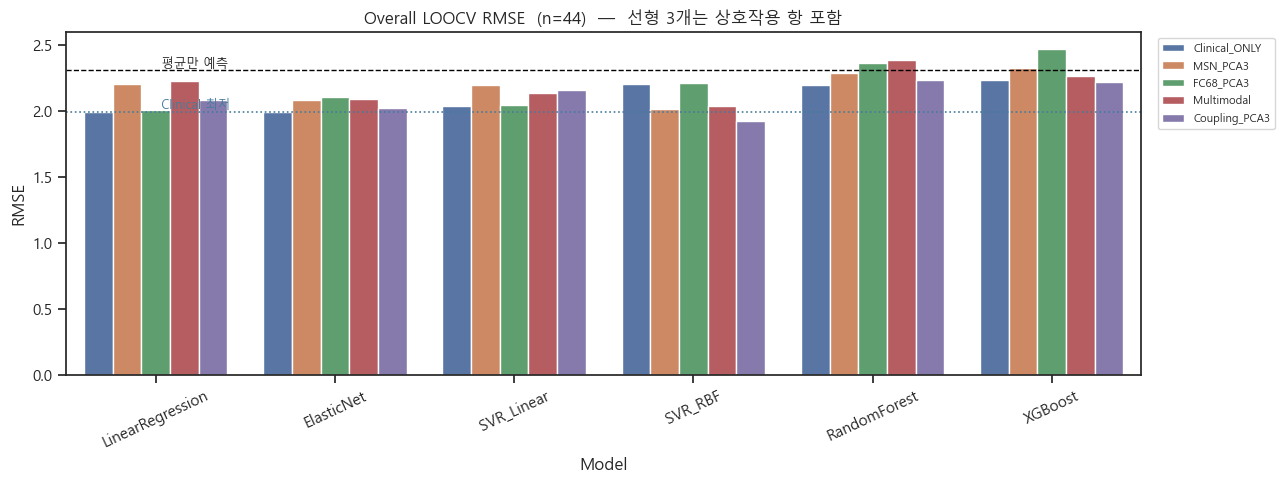

In [10]:
# ==========================================================
# 9. VISUALIZATION
# ==========================================================
sns.set_theme(style="ticks")
plt.rcParams['font.sans-serif'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

ov_long = res[res.Scope == 'Overall']
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=ov_long, x='Model', y='RMSE', hue='Data Type', hue_order=DATA_TYPES, ax=ax)
ax.axhline(baseline_rmse, color='black', ls='--', lw=1)
ax.text(0.01, baseline_rmse, ' 평균만 예측', va='bottom', fontsize=9)
clin = ov_long.loc[ov_long['Data Type'] == 'Clinical_ONLY', 'RMSE'].min()
ax.axhline(clin, color='#457B9D', ls=':', lw=1.2)
ax.text(0.01, clin, ' Clinical 최저', va='bottom', fontsize=9, color='#457B9D')
ax.set_title('Overall LOOCV RMSE  (n=44)  —  선형 3개는 상호작용 항 포함')
ax.tick_params(axis='x', rotation=25)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [11]:
# ==========================================================
# 10. 하이퍼파라미터 안정성 (돌린 모든 조합)
# ==========================================================
for (dt, name, v), plist in best_params_log.items():
    vc = pd.Series(plist).value_counts()
    share = vc.iloc[0] / vc.sum()
    flag = '' if share >= 0.5 else '   <-- 불안정'
    print(f"[{dt} / {name} / {v}] 고유 {len(vc)}개, 최빈 {share:.0%}{flag}")

[Clinical_ONLY / LinearRegression / base] 고유 1개, 최빈 100%
[Clinical_ONLY / ElasticNet / base] 고유 1개, 최빈 100%
[Clinical_ONLY / SVR_Linear / base] 고유 12개, 최빈 43%   <-- 불안정
[Clinical_ONLY / SVR_RBF / base] 고유 7개, 최빈 84%
[Clinical_ONLY / RandomForest / base] 고유 5개, 최빈 61%
[Clinical_ONLY / XGBoost / base] 고유 4개, 최빈 86%
[MSN_PCA3 / LinearRegression / base] 고유 1개, 최빈 100%
[MSN_PCA3 / LinearRegression / inter] 고유 1개, 최빈 100%
[MSN_PCA3 / ElasticNet / base] 고유 6개, 최빈 86%
[MSN_PCA3 / ElasticNet / inter] 고유 4개, 최빈 41%   <-- 불안정
[MSN_PCA3 / SVR_Linear / base] 고유 5개, 최빈 32%   <-- 불안정
[MSN_PCA3 / SVR_Linear / inter] 고유 4개, 최빈 66%
[MSN_PCA3 / SVR_RBF / base] 고유 2개, 최빈 95%
[MSN_PCA3 / RandomForest / base] 고유 5개, 최빈 43%   <-- 불안정
[MSN_PCA3 / XGBoost / base] 고유 3개, 최빈 73%
[FC68_PCA3 / LinearRegression / base] 고유 1개, 최빈 100%
[FC68_PCA3 / LinearRegression / inter] 고유 1개, 최빈 100%
[FC68_PCA3 / ElasticNet / base] 고유 3개, 최빈 93%
[FC68_PCA3 / ElasticNet / inter] 고유 7개, 최빈 66%
[FC68_PCA3 / SVR_Linear / base] 고유 10

## 결과 읽는 법

1. **상호작용 항이 이득인가** (5번 셀): `d_inter_gain = RMSE(base) - RMSE(inter)`가 +여야 이득이다.
   선형 3개 모델 x 4개 피처셋 = 12개 조합에서 **고르게** + 가 나와야 한다.
   한두 조합만 + 면 n=44에 컬럼만 늘린 잡음으로 읽는다 (Coupling은 컬럼 5개 → 8개, Multimodal은 8개 → 14개).
2. **coupling이 정보를 더하는가** (8번 셀): `d_Coup_vs_Clin`이 +. Active/Sham 각각에서 본다.
3. **Active/Sham 비교 주의**: LOOCV 예측은 44명 전체로 학습한 것이고 군은 평가 단계에서만 나눈다.
   군별 RMSE는 표본이 25명/19명으로 작아 흔들리며, R2는 군마다 vas 분산이 달라 군 간 직접 비교에 쓰지 않는다.
4. **비선형 3개 모델의 sanity check**: 이 모델들은 상호작용 항을 넣지 않았고 treatment 코딩 변경은
   StandardScaler 뒤에서 상쇄되므로, `automl_multimodal_MSN_FC68_coupling_PCA3.ipynb`의 값과 사실상 같아야 한다.
   다르면 파이프라인 어딘가가 어긋난 것이다.
5. **하지 말 것**: 상호작용이 + 나온 조합만 골라 보고하기, PCA 성분 수를 결과 보고 바꾸기.

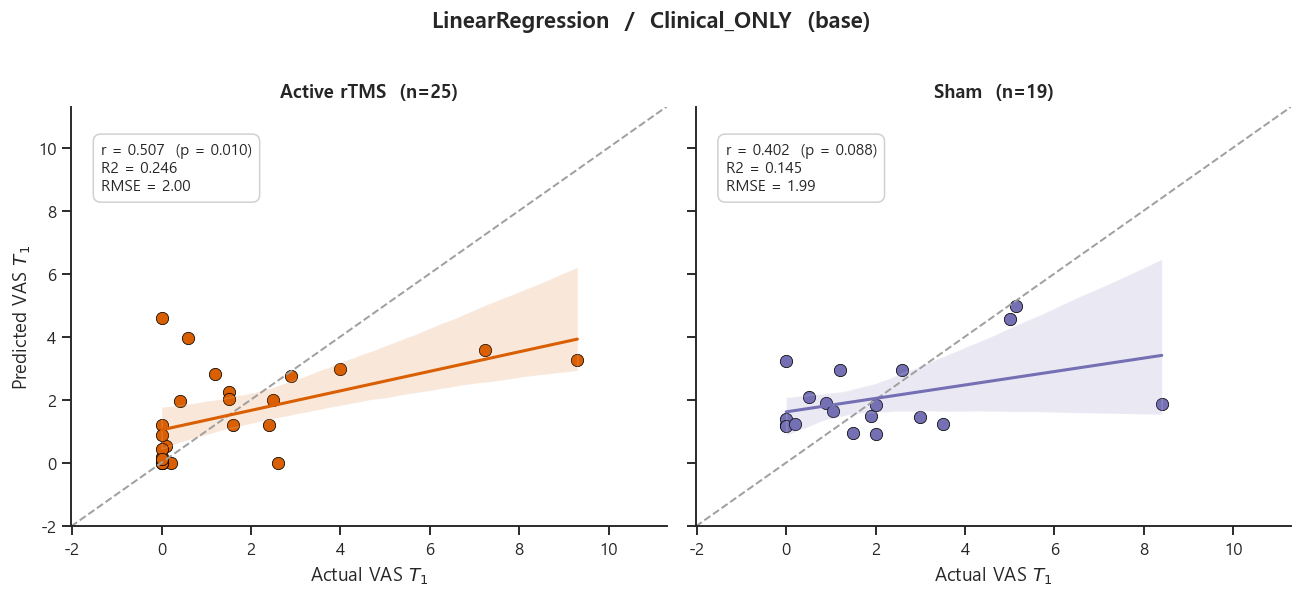

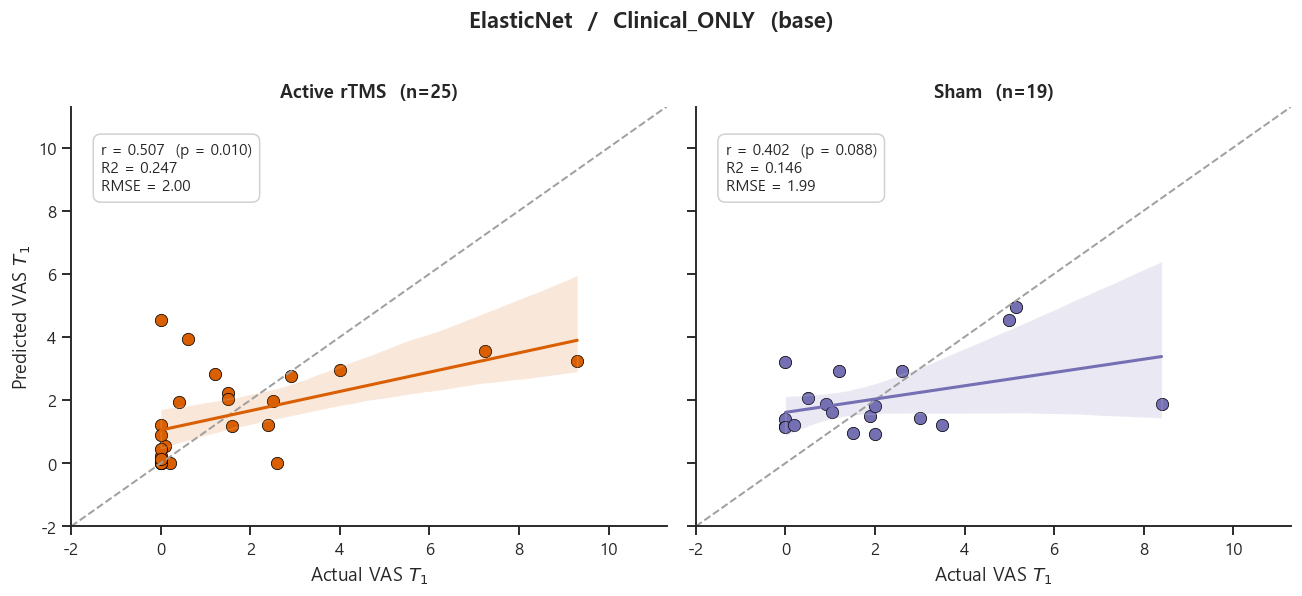

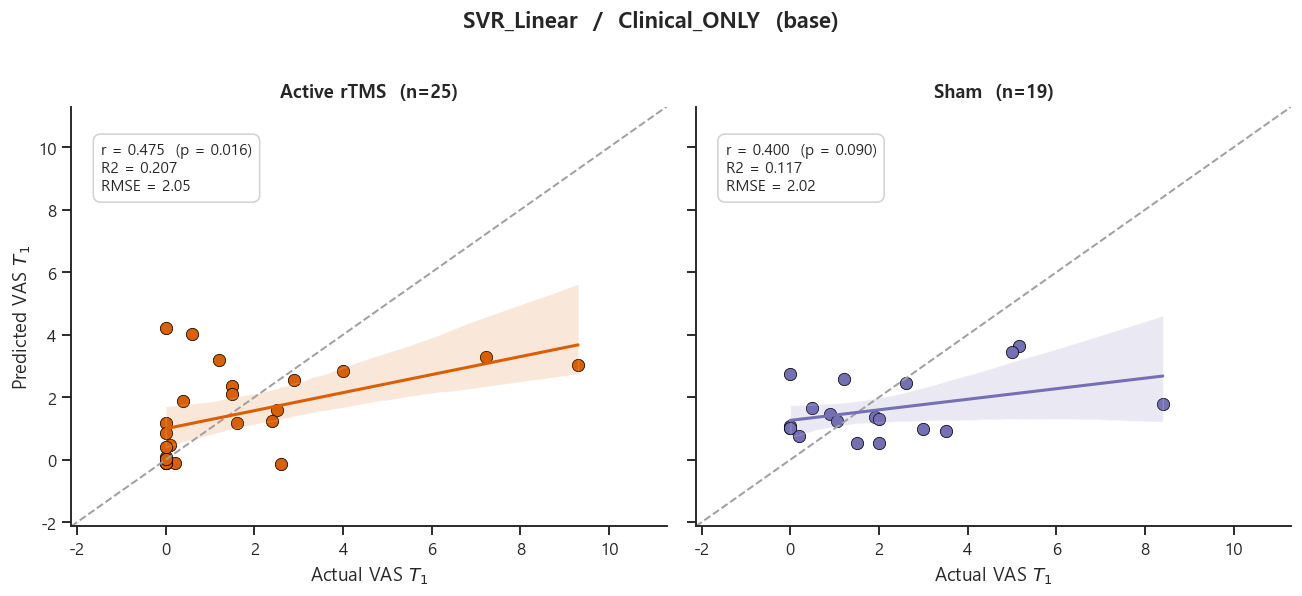

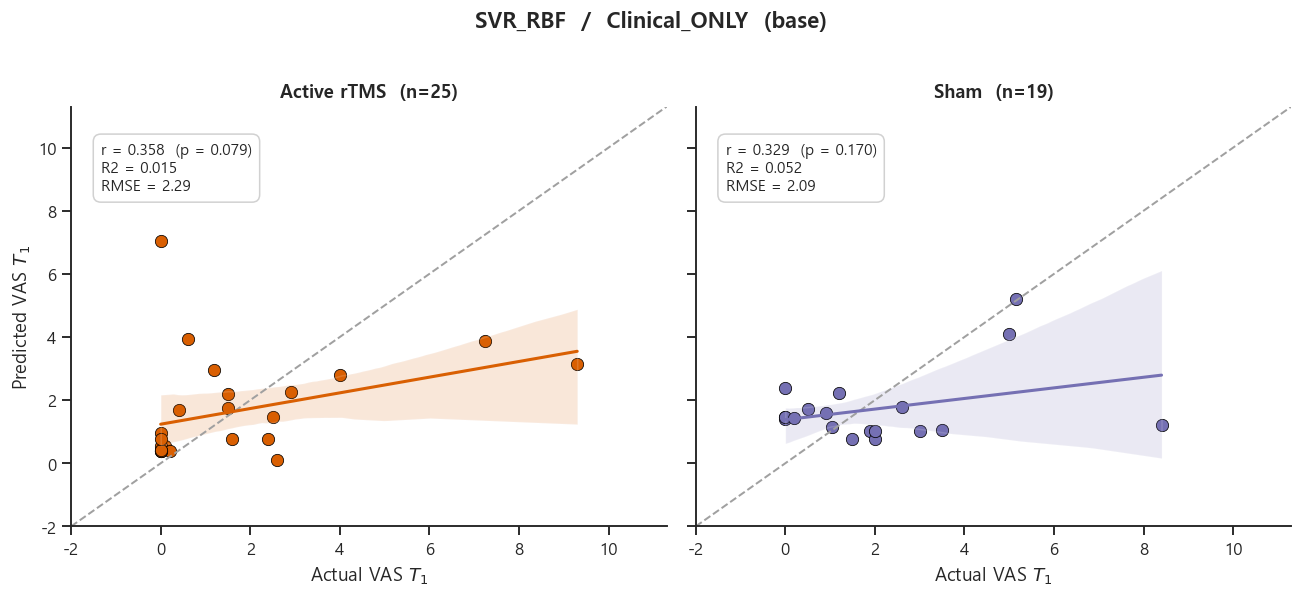

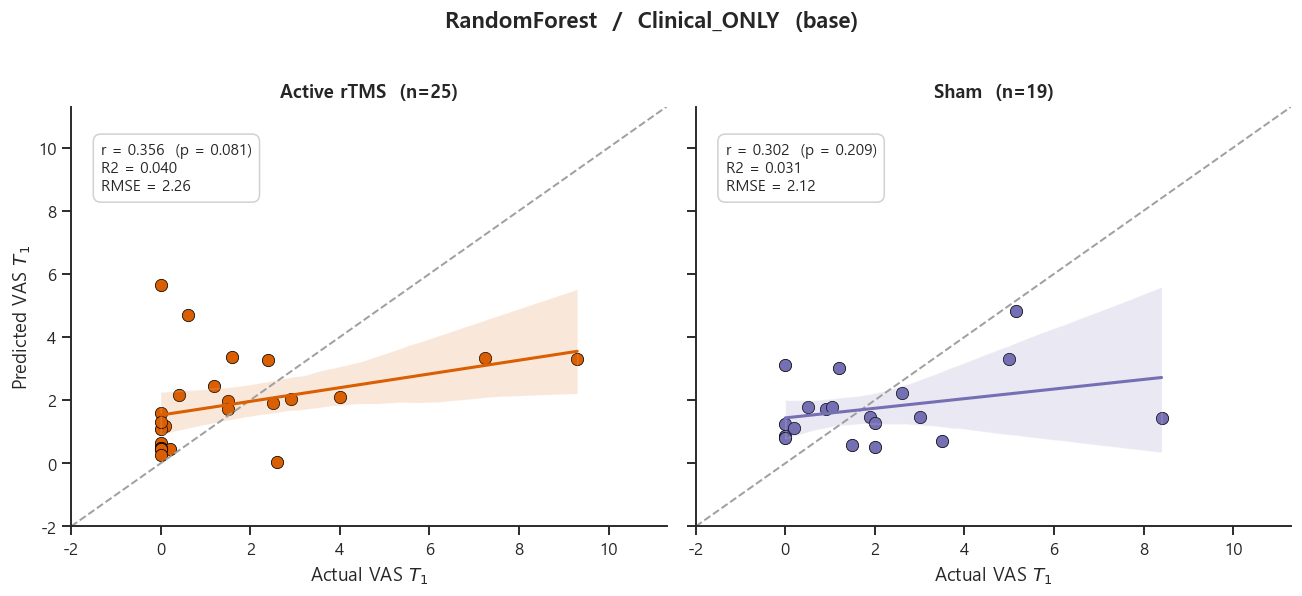

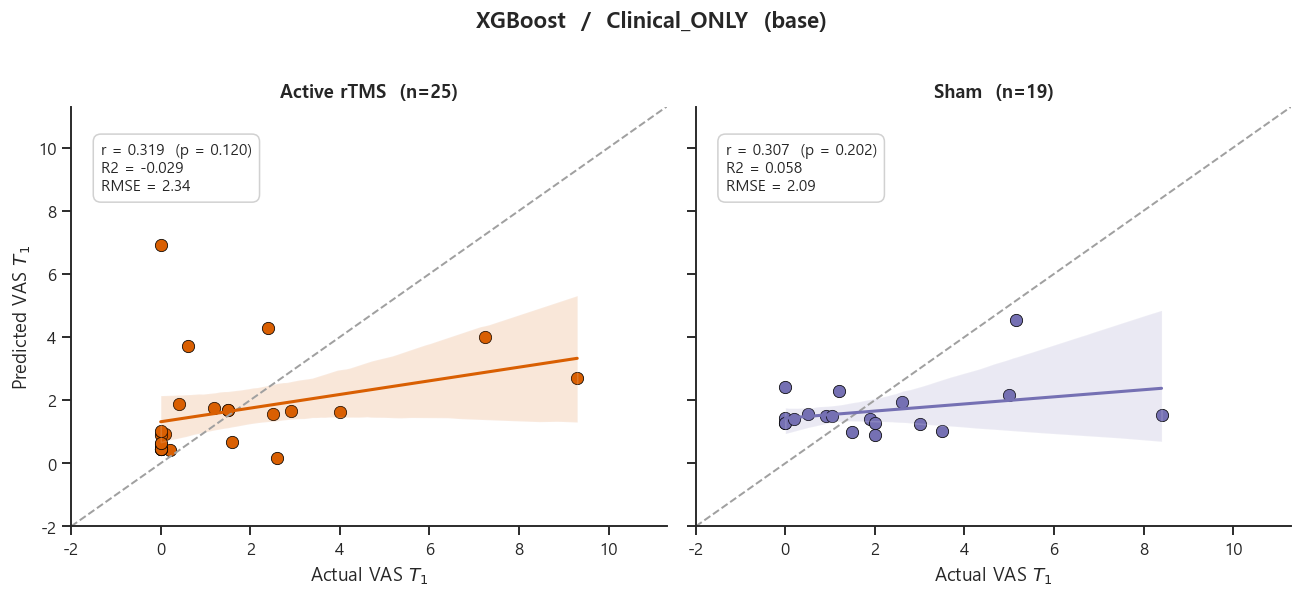

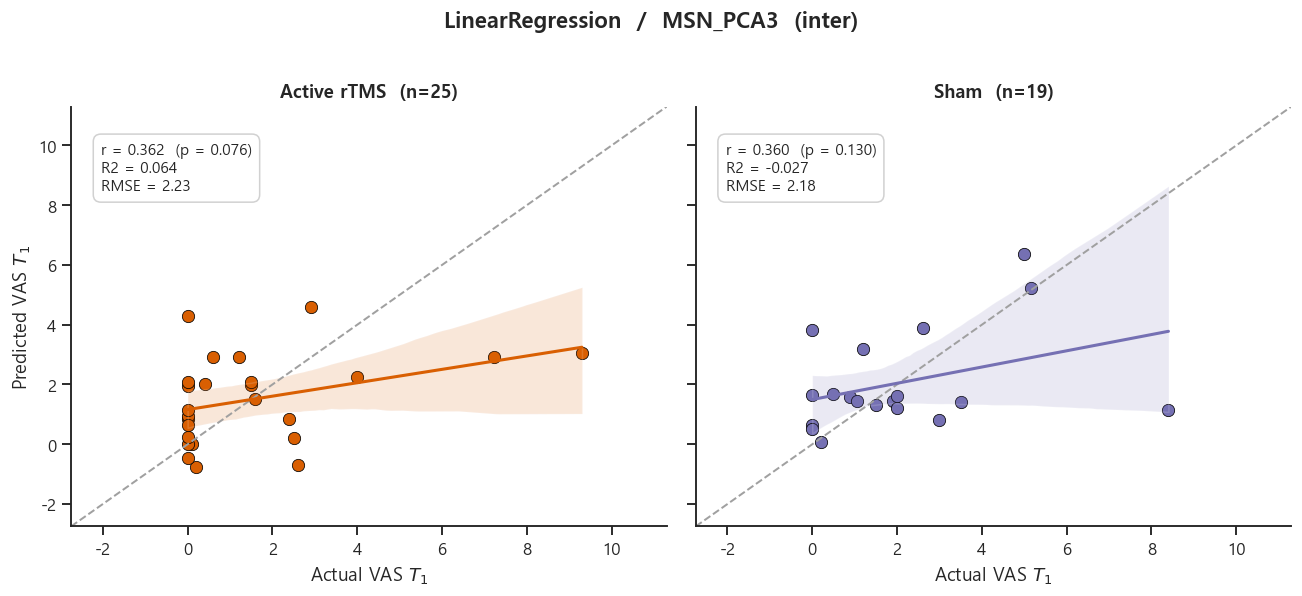

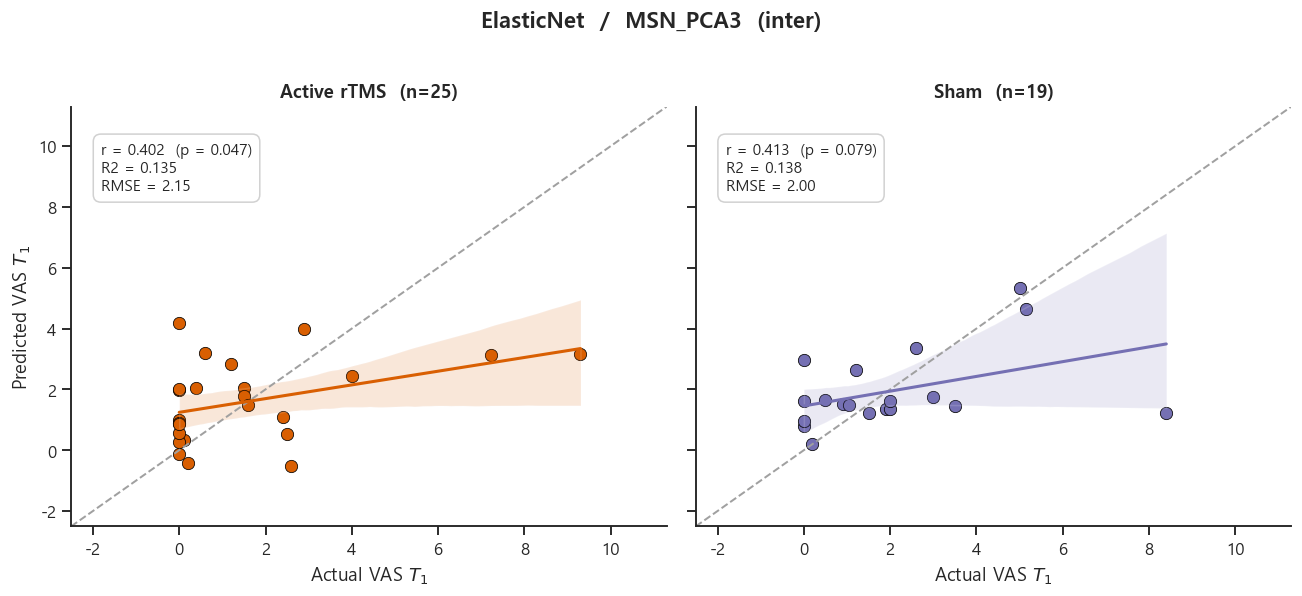

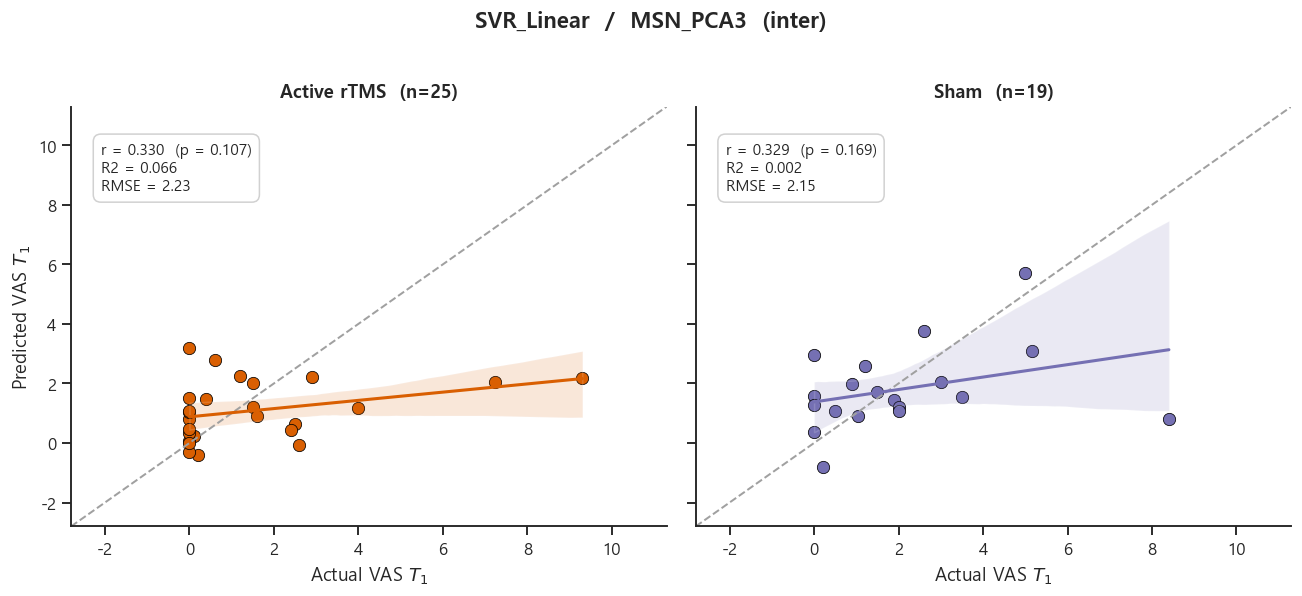

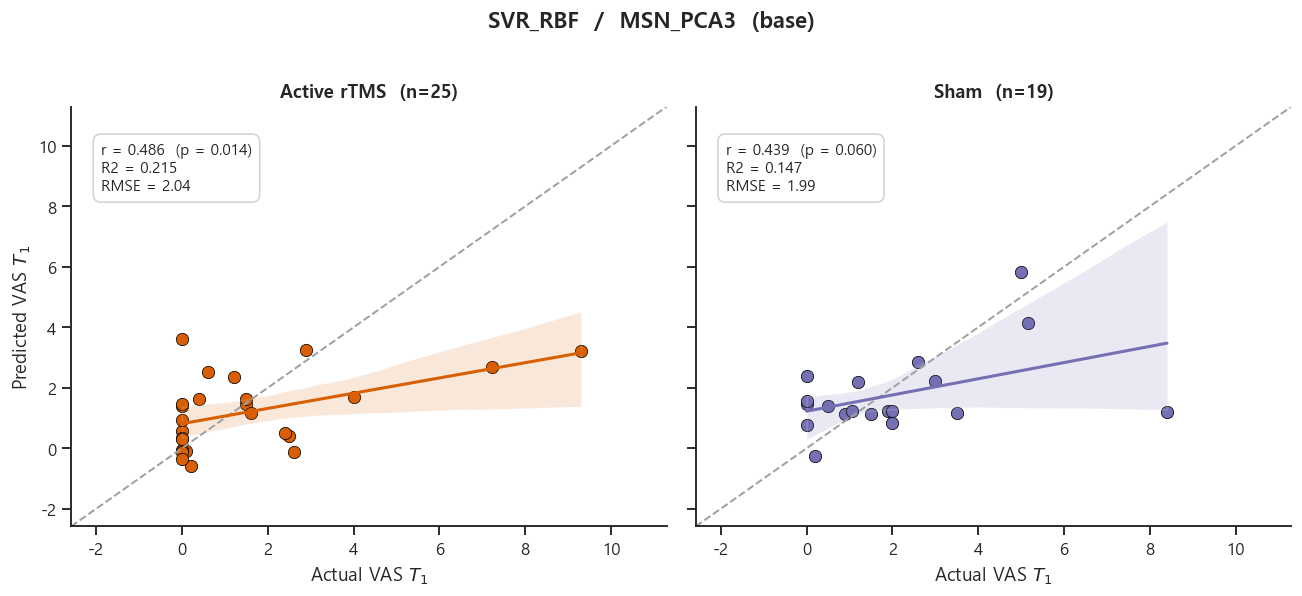

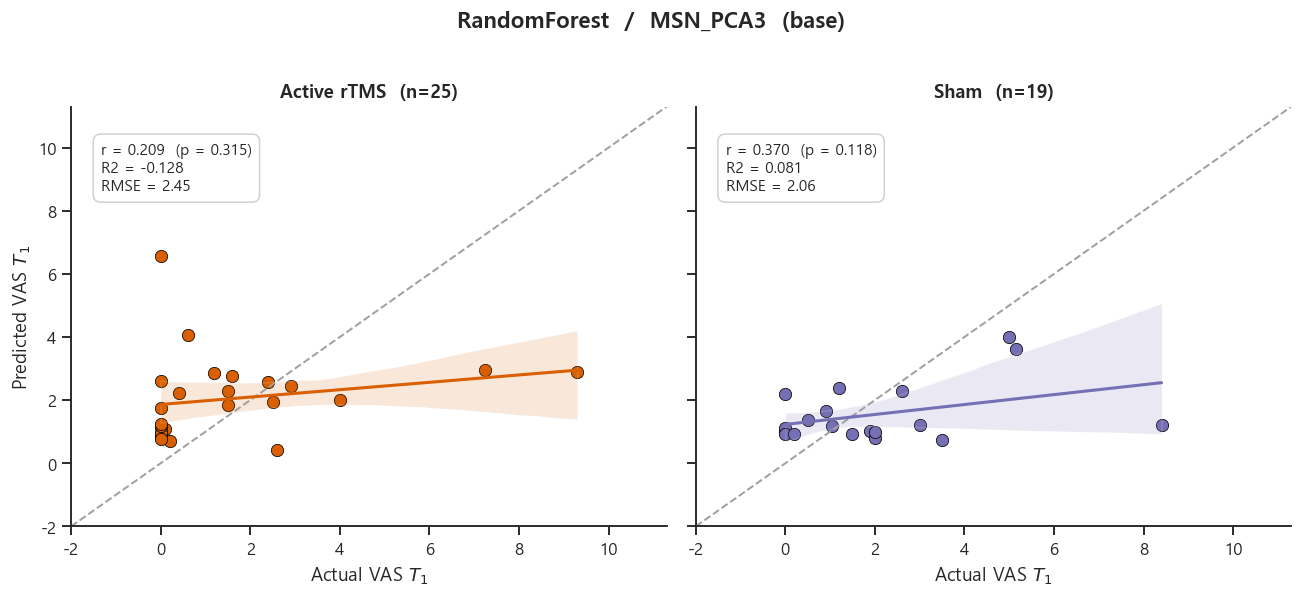

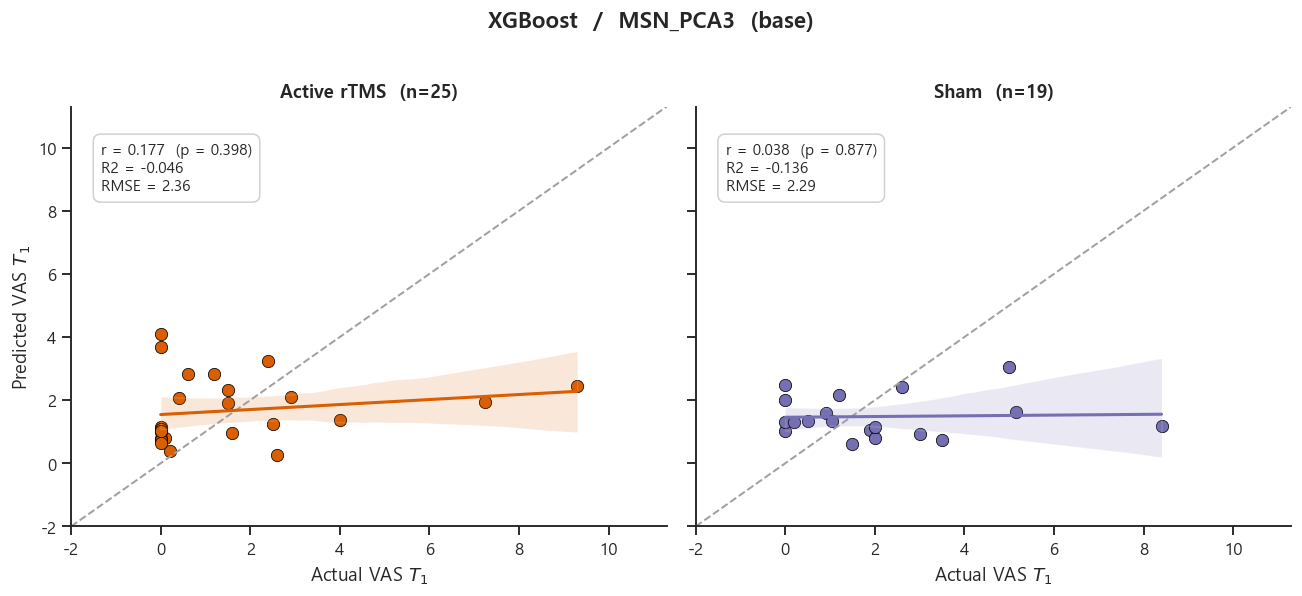

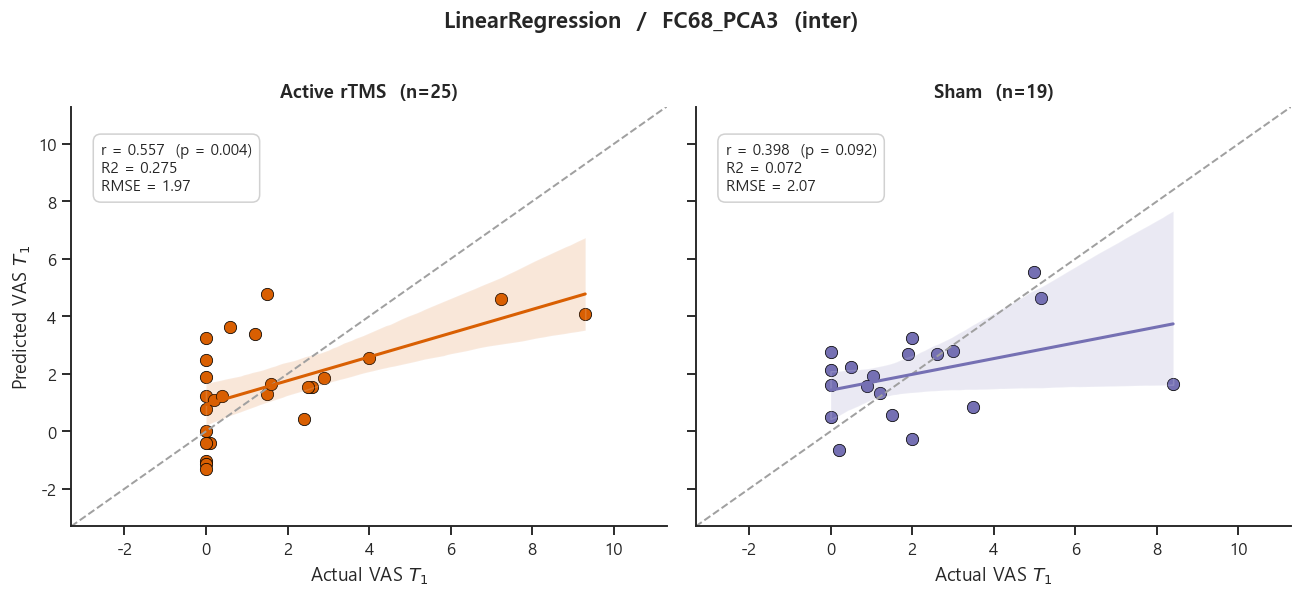

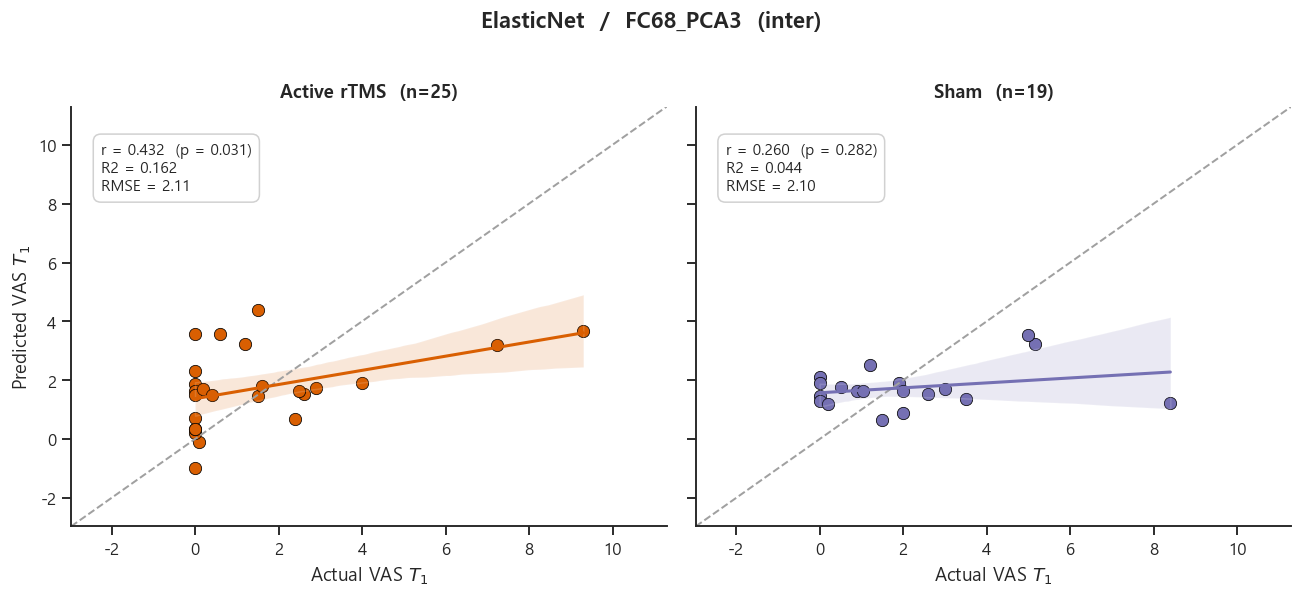

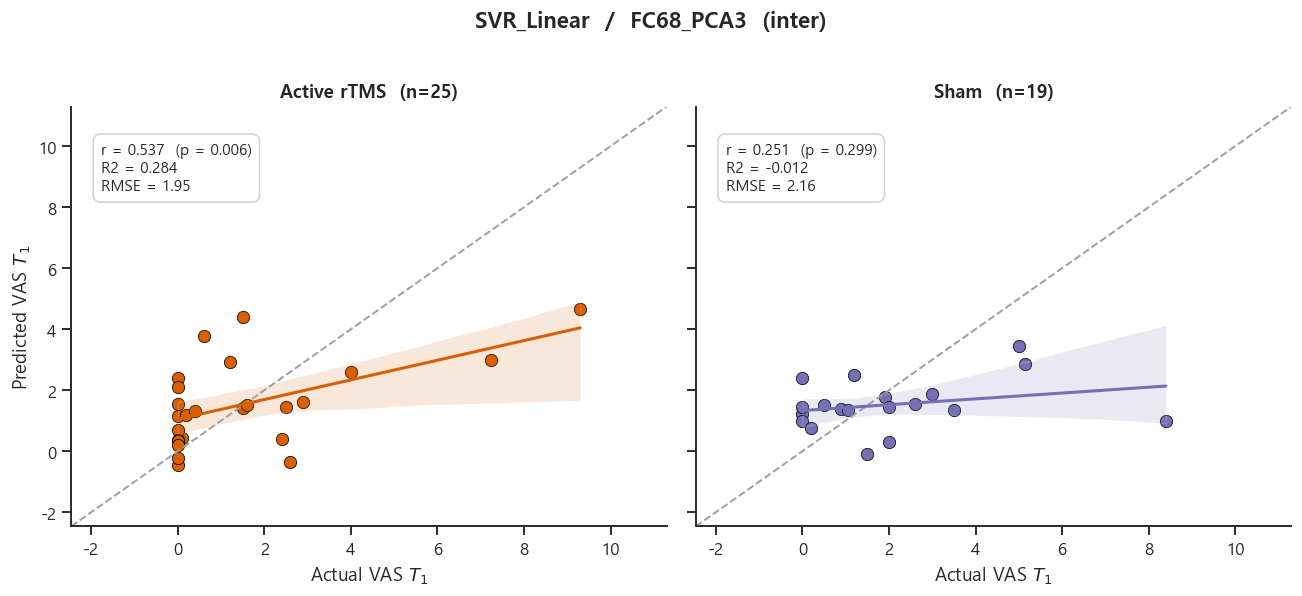

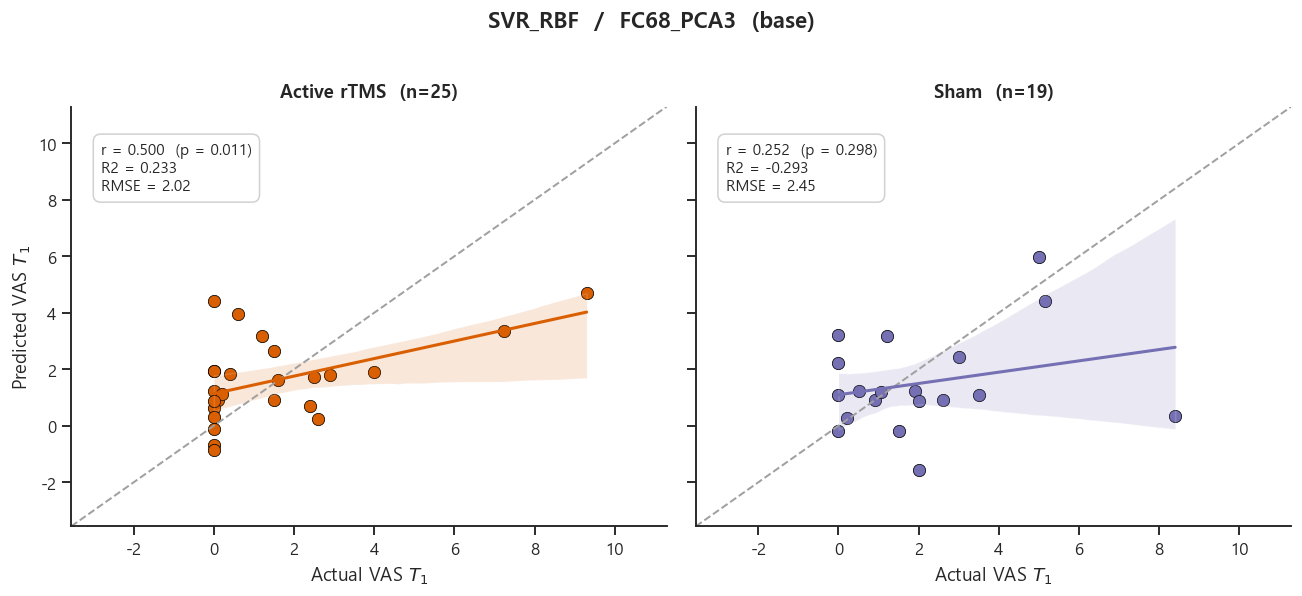

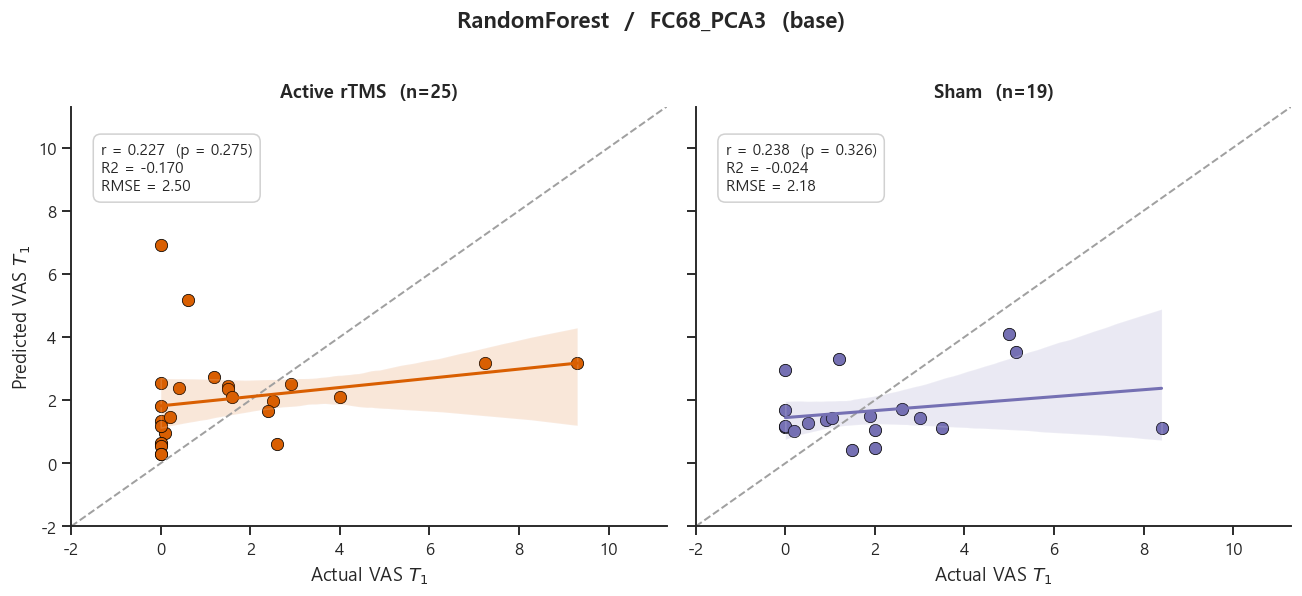

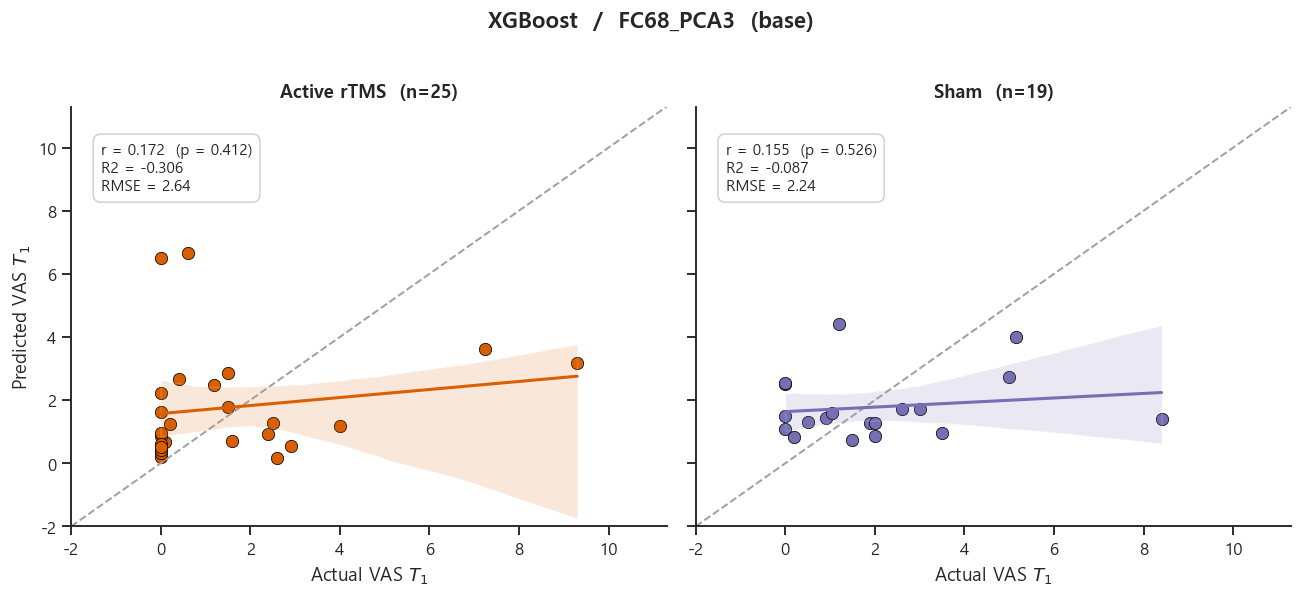

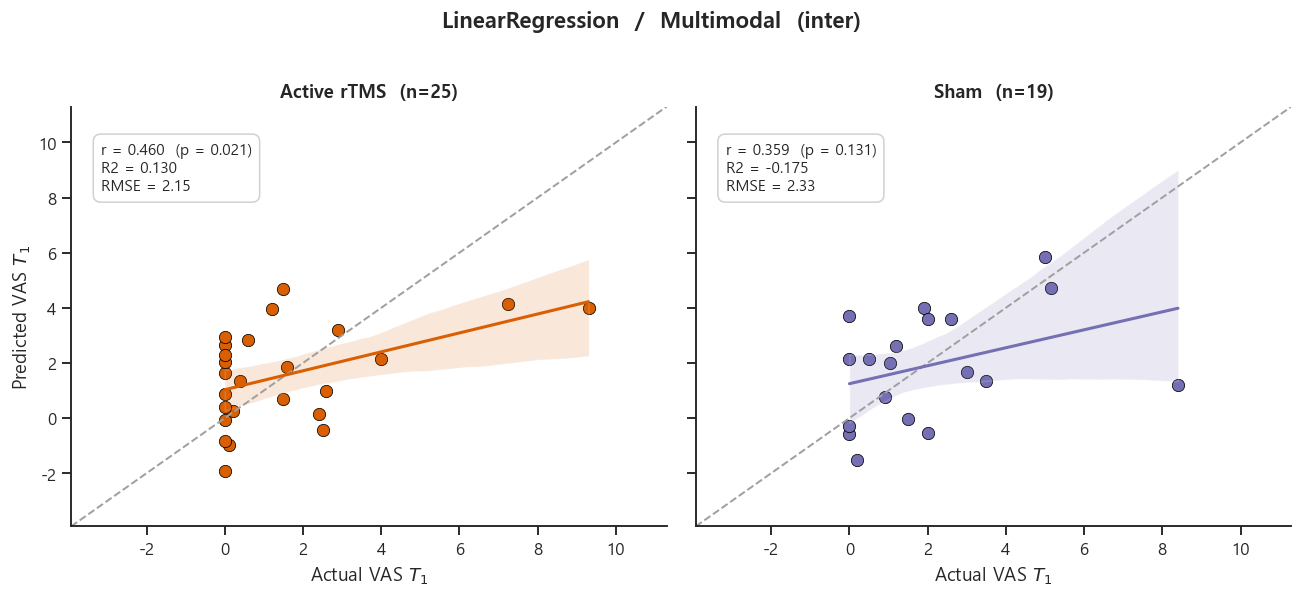

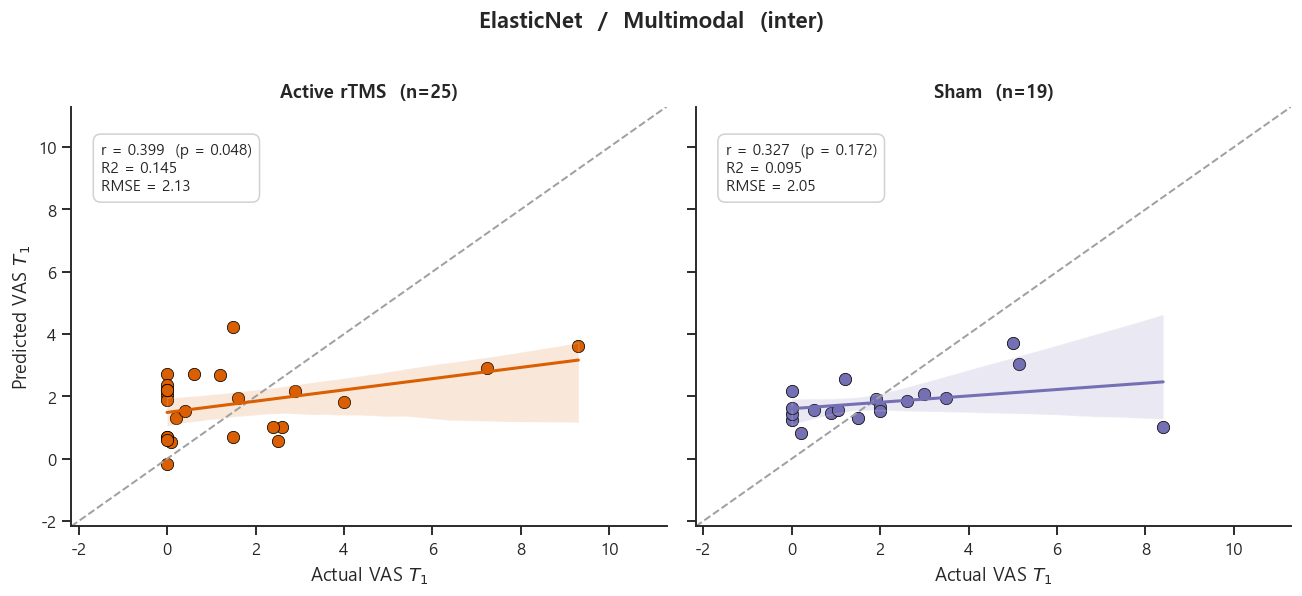

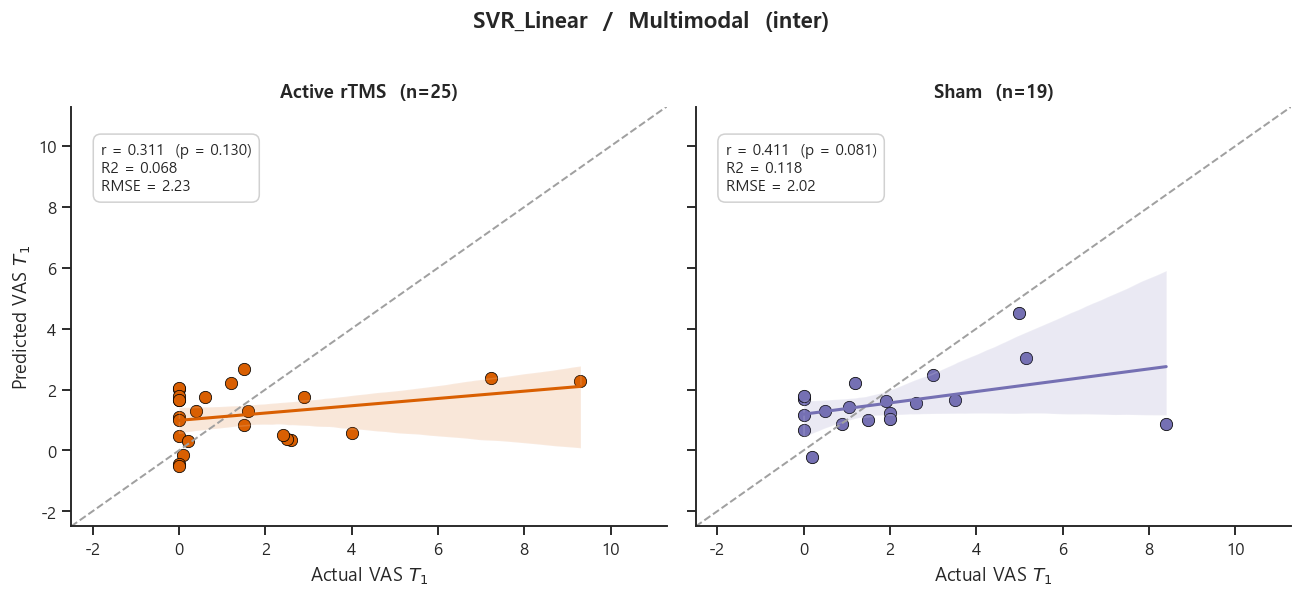

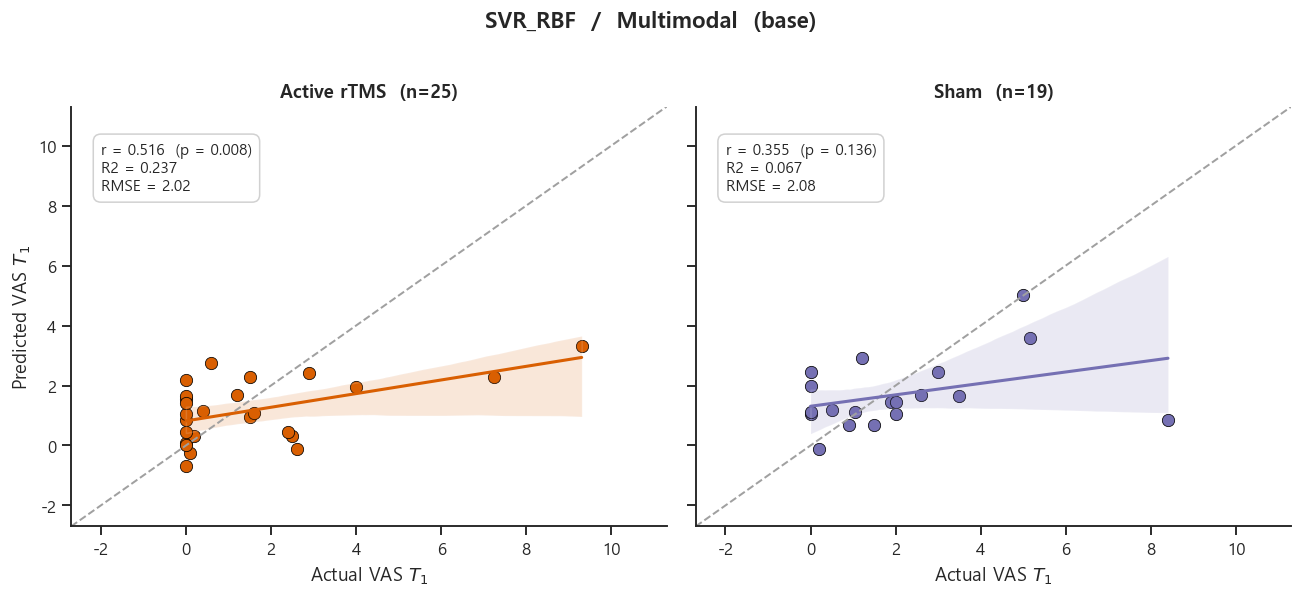

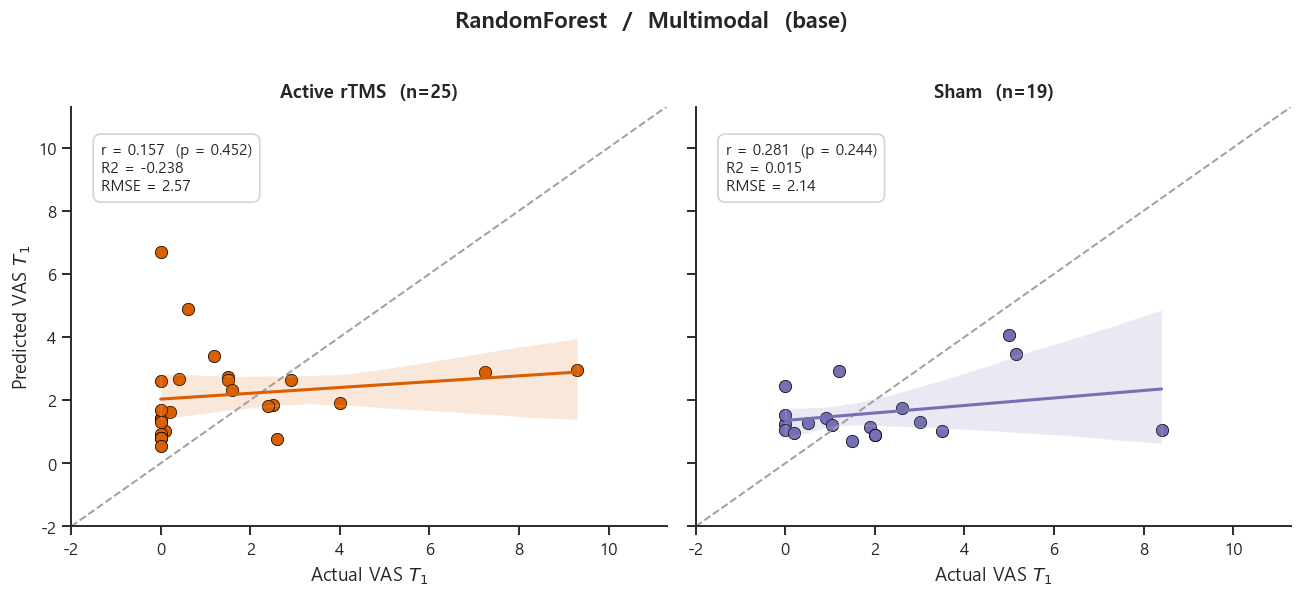

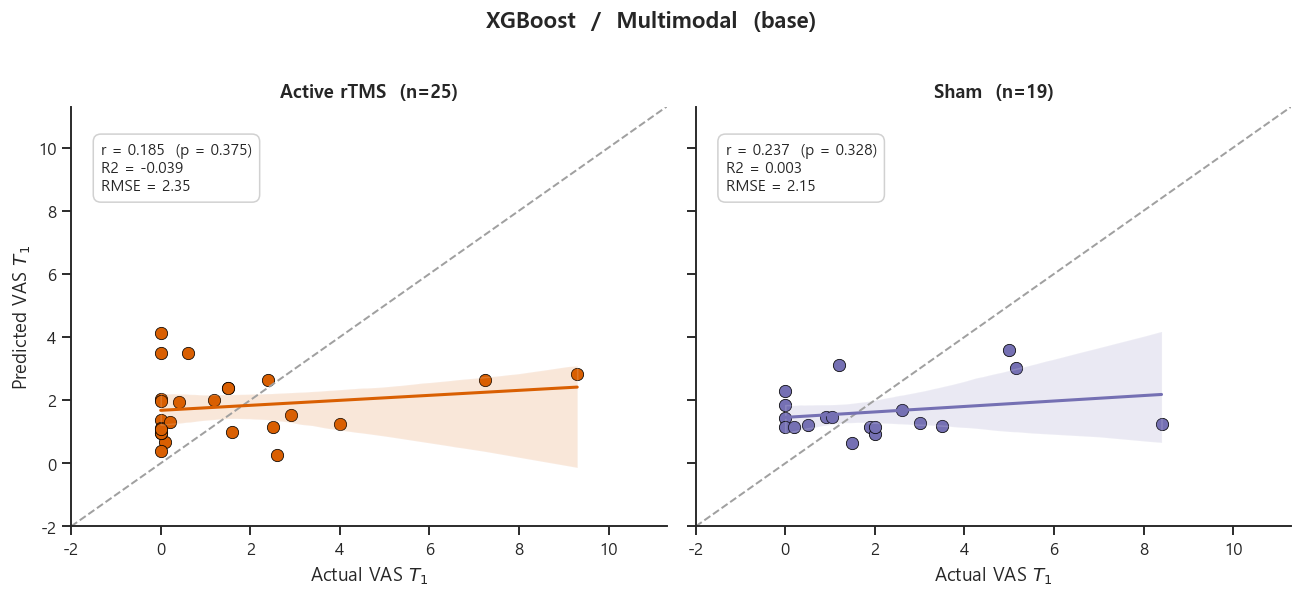

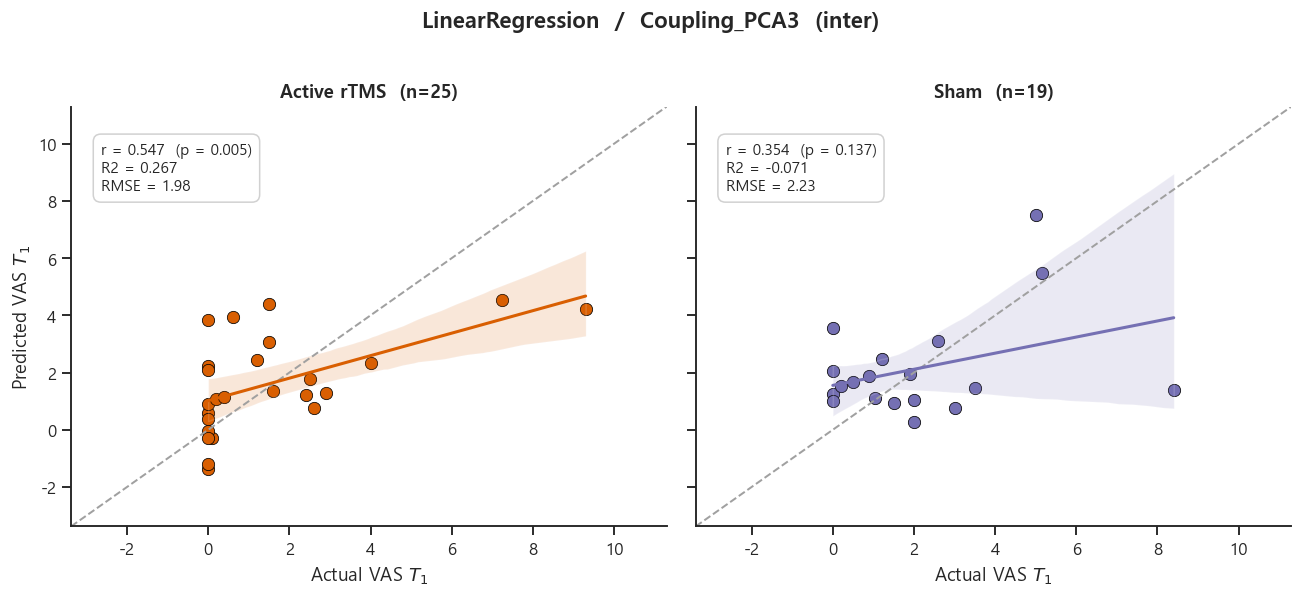

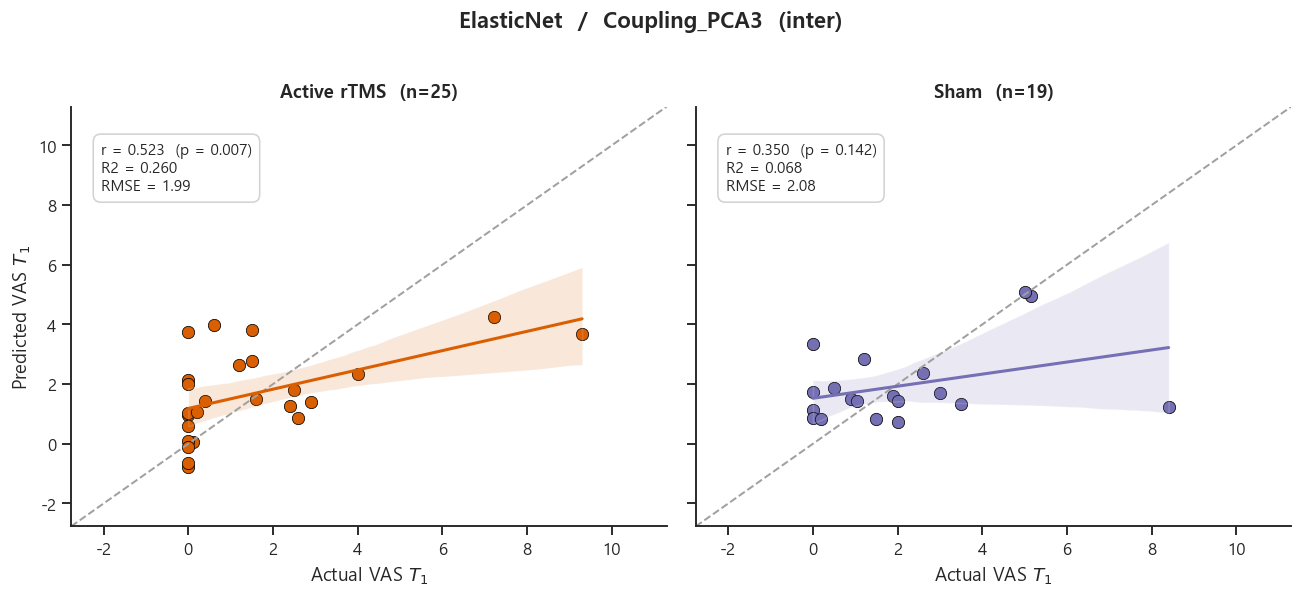

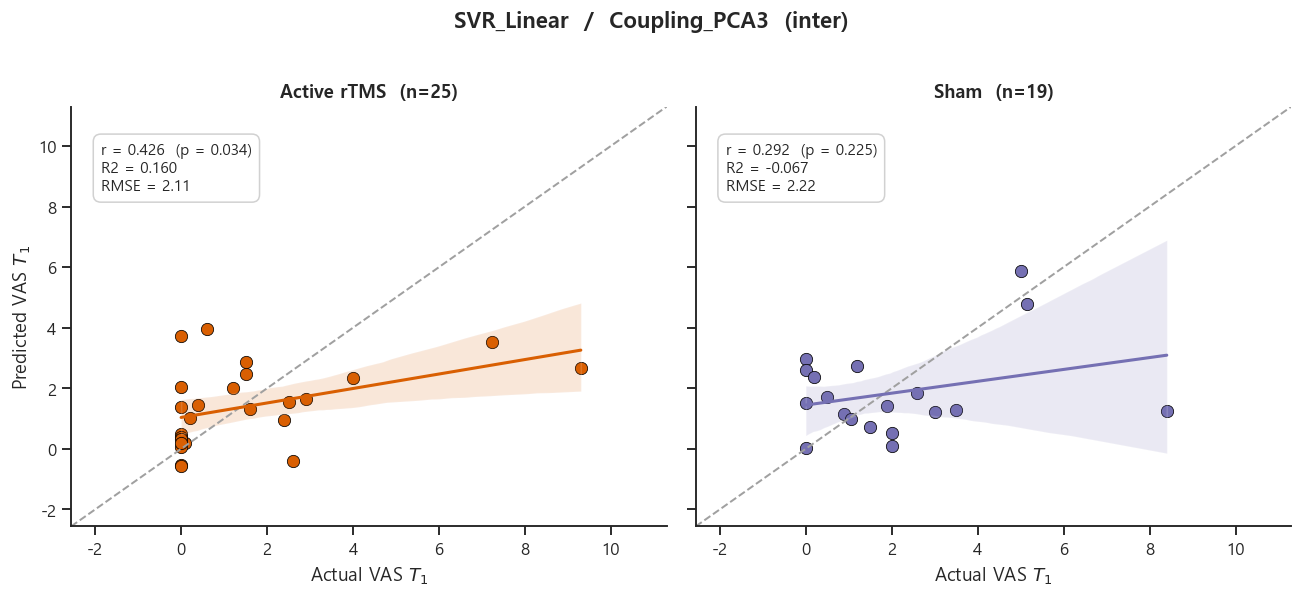

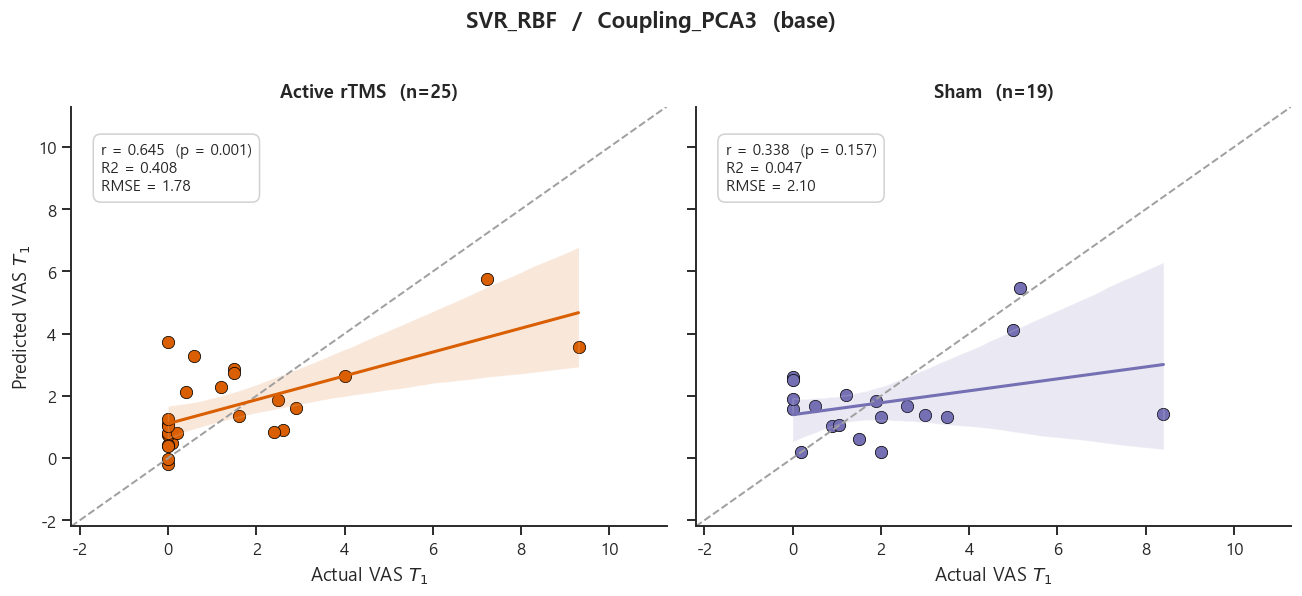

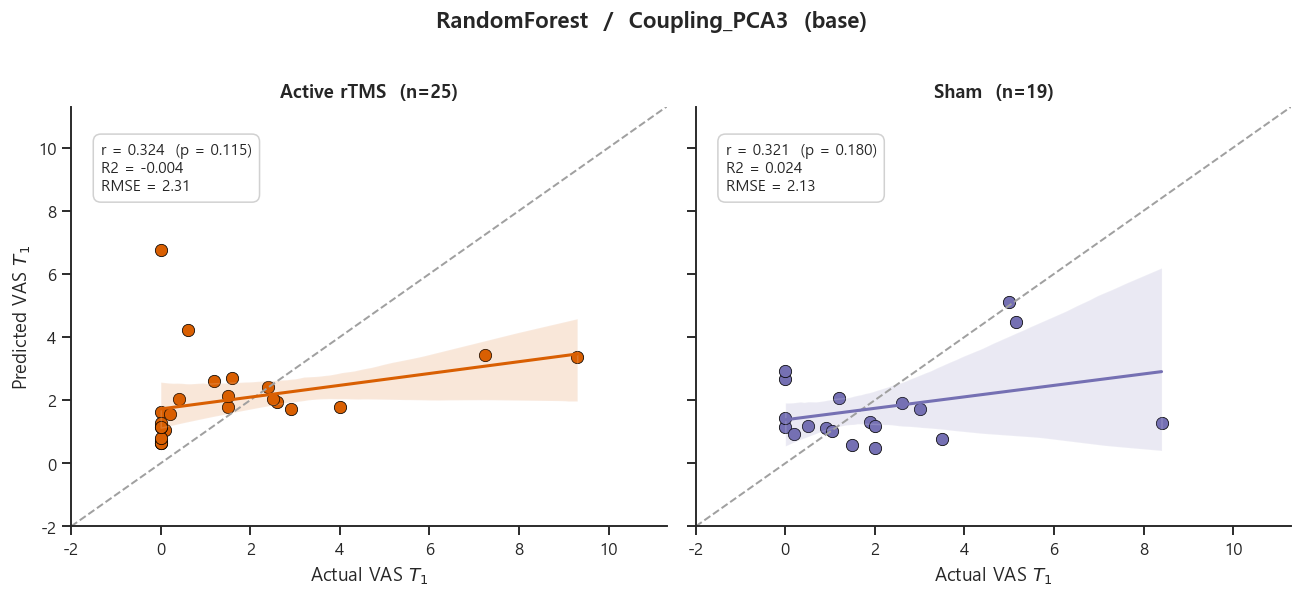

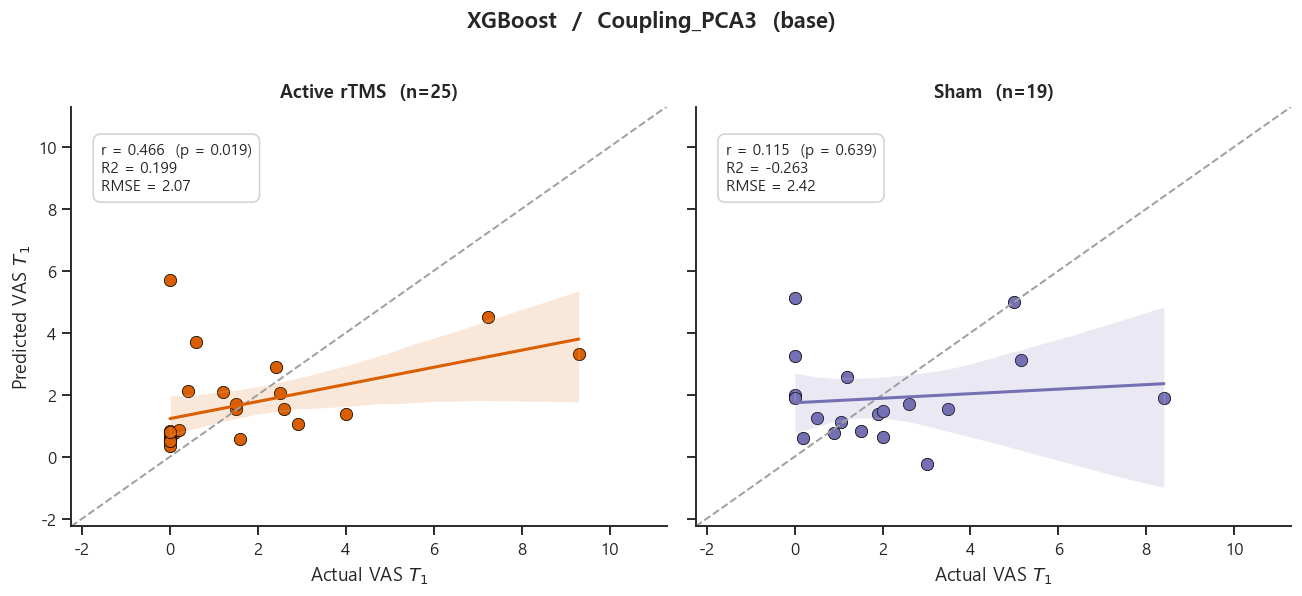

In [12]:
# ==========================================================
# 11. 산점도 — Active rTMS vs Sham (Clinical_ONLY 포함 5개 피처셋)
#     LOOCV 예측은 44명 전체로 학습한 것이고, 그림에서만 그룹을 나눠 본다.
# ==========================================================
PLOT_DATA_TYPES = DATA_TYPES          # 줄이려면 여기서 빼기
PLOT_MODELS = list(models)            # 예: ['ElasticNet', 'SVR_Linear'] 로 줄일 수 있다
groups2 = ['Active rTMS', 'Sham']
palette = {'Active rTMS': '#D95F02', 'Sham': '#7570B3'}
grp_full = np.where(TRT == 1, 'Active rTMS', 'Sham')

for (dt, name), yp in pred_primary.items():
    if dt not in PLOT_DATA_TYPES or name not in PLOT_MODELS:
        continue
    pdf = pd.DataFrame({'Actual': y_true, 'Predicted': yp, 'Group': grp_full})
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.3), sharex=True, sharey=True, dpi=110)
    lo = min(pdf['Actual'].min(), pdf['Predicted'].min()) - 2
    hi = max(pdf['Actual'].max(), pdf['Predicted'].max()) + 2
    for i, g in enumerate(groups2):
        ax = axes[i]
        sub = pdf[pdf['Group'] == g]
        r, pv = pearsonr(sub['Actual'], sub['Predicted'])
        ax.plot([lo, hi], [lo, hi], color='#A0A0A0', ls='--', lw=1.3)
        sns.scatterplot(data=sub, x='Actual', y='Predicted', color=palette[g], s=65,
                        edgecolor='black', linewidth=0.5, ax=ax)
        sns.regplot(data=sub, x='Actual', y='Predicted', ax=ax, scatter=False,
                    color=palette[g], line_kws={'linewidth': 2})
        ax.set_title(f'{g}  (n={len(sub)})', fontweight='bold')
        ax.text(0.05, 0.80,
                f"r = {r:.3f}  (p = {pv:.3f})\n"
                f"R2 = {r2_score(sub['Actual'], sub['Predicted']):.3f}\n"
                f"RMSE = {np.sqrt(np.mean((sub['Actual'] - sub['Predicted']) ** 2)):.2f}",
                transform=ax.transAxes, fontsize=10,
                bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='#CCC', alpha=0.9))
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_xlabel('Actual VAS $T_1$')
        if i == 0:
            ax.set_ylabel('Predicted VAS $T_1$')
    fig.suptitle(f'{name}  /  {dt}  ({PRIMARY[(dt, name)]})', fontweight='bold', y=1.02)
    sns.despine()
    plt.tight_layout()
    plt.show()